<a href="https://colab.research.google.com/github/vad-source/AIMLROBOTICS/blob/main/MeasurementModel/Sensor_Modelling_for_Pose_Estimation_with_Velocity_Motion_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## AIMLROBOTICS
**Designed by:** RAJA VADHANA PRABHAKAR  
**Organization:** BITS PILANI WILP  
**Purpose:** Academic Training / Proof of Concept  

---
#### Attribution & AI Disclosure
- **Original Design:** The logic, architecture, and modular structure of this notebook were designed by the author.
- **Development Assistance:** Generative AI (e.g., ChatGPT/Claude/Copilot) was used for coding implementation and debugging support.
- **License:** This work is licensed under the [Apache License 2.0](https://apache.org).

**Objective:**
>> To familiarize with the notion of measurement model with gaussian noise

>> Assume a mobile robot is moving an area with three obstacles for 10 steps, sensing obstacles in front, scoring the perceived data for correcting the predicted pose. The enviornment is discretized into grids for this toy problem

>> Following models are applied with velocity motion model and scoring P(Z|X,m) the measurement.


*   Beam Based Measurement model
*   Correlation Based Measurement model(check the probabilisitic section below)
*   Likelihood Measurement Model
*   Feature Based Measurement model (Note : Only a representatives of the beams are used to simulate the feature design in this toy problem. DBSCAN clustering is used to extract few unique beam's data for feature creation)
*   Neural Network based (BeamNet) Measurement model




In [ ]:
#!pip install pybullet opencv-python matplotlib numpy

> Move
>> Sense obstacles using Beams
>>> Visualize the Beams
>>>> EStimate the multiple candiate POSES of Robot or Object
>>>>> Compare it with the Map using Correlation
>>>>>> Refine the POSE estimation of Robot or Object (AMCL or Scan Matching uses this technique)

In [ ]:
import pybullet as p
import pybullet_data
import numpy as np
import time
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import display, clear_output
import cv2

Set up Environment
> Load the bot
> > Optionally add obstacles

In [ ]:
# Connect to PyBullet GUI
#p.connect(p.GUI)
physicsClient = p.connect(p.DIRECT)
p.setAdditionalSearchPath(pybullet_data.getDataPath())
p.setGravity(0, 0, -9.81)


In [ ]:
# Load ground and robot
p.loadURDF("plane.urdf")
robot_id = p.loadURDF("husky/husky.urdf", basePosition=[0, 0, 0.1])

In [ ]:
# Load some obstacles
obstacles = [(2, 1), (3, -1), (4, 0)]
for x, y in obstacles:
    p.loadURDF("cube.urdf", basePosition=[x, y, 0.5])

Map the world on to an occupany GRID

In [ ]:
MAP_SIZE = 100  # 100x100 grid
MAP_RESOLUTION = 0.1  # 10 cm per cell
grid_map = np.full((MAP_SIZE, MAP_SIZE), 0.5)  # 0.5 = unknown, 0 = free, 1 = occupied

In [ ]:
def world_to_map(x, y):
    col = int((x + (MAP_SIZE * MAP_RESOLUTION / 2)) / MAP_RESOLUTION)
    row = int((y + (MAP_SIZE * MAP_RESOLUTION / 2)) / MAP_RESOLUTION)
    return col, row


# Add known obstacles to the map
for x, y in obstacles:
    ix, iy = world_to_map(x, y)
    x0, x1 = max(ix - 1, 0), min(ix + 2, MAP_SIZE)
    y0, y1 = max(iy - 1, 0), min(iy + 2, MAP_SIZE)
    grid_map[y0:y1, x0:x1] = 1  # note: row=y, col=x

In [ ]:
def bresenham_ray(x0, y0, x1, y1):
    # Returns grid cells (row, col) along the ray from (x0,y0) to (x1,y1), inclusive
    c0, r0 = world_to_map(x0, y0)
    c1, r1 = world_to_map(x1, y1)
    points = []
    dc = abs(c1 - c0); dr = abs(r1 - r0)
    sc = 1 if c0 < c1 else -1
    sr = 1 if r0 < r1 else -1
    err = dc - dr
    c, r = c0, r0
    while True:
        points.append((r, c))
        if c == c1 and r == r1: break
        e2 = 2 * err
        if e2 > -dr: err -= dr; c += sc
        if e2 <  dc: err += dc; r += sr
    return points

def update_map(map_data, beam_endpoints, robot_pose, hit_max=True):
    # beam_endpoints are world-frame points
    rx, ry = robot_pose[0], robot_pose[1]
    for xw, yw in beam_endpoints:
        cells = bresenham_ray(rx, ry, xw, yw)
        if not cells: continue
        # Mark free along the ray except last cell
        for (r, c) in cells[:-1]:
            if 0 <= r < MAP_SIZE and 0 <= c < MAP_SIZE:
                map_data[r, c] = 0
        # Mark occupied at the endpoint
        r_end, c_end = cells[-1]
        if 0 <= r_end < MAP_SIZE and 0 <= c_end < MAP_SIZE:
            map_data[r_end, c_end] = 1 if hit_max else map_data[r_end, c_end]

Sensor Model & Visualize the Beams & Range Distance of 60 means at a time

In [ ]:
def simulate_lidar(robot_id, angle_range=(-np.pi/2, np.pi/2), max_distance=5.0, num_rays=60):
    position, orientation = p.getBasePositionAndOrientation(robot_id)
    yaw = p.getEulerFromQuaternion(orientation)[2]

    sensor_origin = np.array(position); sensor_origin[2] = 0.3

    rays_from, rays_to = [], []
    for i in range(num_rays):
        angle = yaw + angle_range[0] + (i / (num_rays - 1)) * (angle_range[1] - angle_range[0])
        direction = np.array([np.cos(angle), np.sin(angle), 0])
        rays_from.append(sensor_origin.tolist())
        rays_to.append((sensor_origin + max_distance * direction).tolist())

    results = p.rayTestBatch(rays_from, rays_to)

    # Clear previous debug rays
    global beam_lines
    if 'beam_lines' in globals():
        for line_id in beam_lines:
            p.removeUserDebugItem(line_id)
    beam_lines = []

    distances, beam_endpoints, hits = [], [], []
    for i, res in enumerate(results):
        ray_start = np.array(rays_from[i])
        ray_end = np.array(rays_to[i])
        if res[0] == -1:
            endpoint = ray_end
            hit = False
            dist = max_distance
        else:
            endpoint = np.array(res[3])
            hit = True
            dist = np.linalg.norm(endpoint - ray_start)

        line_id = p.addUserDebugLine(ray_start.tolist(), endpoint.tolist(), [1, 0, 0], lineWidth=1.5, lifeTime=0.1)
        beam_lines.append(line_id)
        distances.append(dist)
        beam_endpoints.append([endpoint[0], endpoint[1]])
        hits.append(hit)

    return distances, beam_endpoints, hits, (position[0], position[1], yaw)

#### Generate candidate Hypothesis

In [ ]:
def generate_candidate_poses(current_pose, num_candidates=20, position_jitter=0.2, angle_jitter=np.pi / 18):
    candidates = []
    x, y, theta = current_pose
    for _ in range(num_candidates):
        dx = np.random.uniform(-position_jitter, position_jitter)
        dy = np.random.uniform(-position_jitter, position_jitter)
        dtheta = np.random.uniform(-angle_jitter, angle_jitter)
        candidates.append((x + dx, y + dy, theta + dtheta))
    return candidates

In [ ]:
def transform_to_world(x, y, theta, dx, dy):
    x_world = x + dx * np.cos(theta) - dy * np.sin(theta)
    y_world = y + dx * np.sin(theta) + dy * np.cos(theta)
    return x_world, y_world

Move
>> Velocity Control
>>> Avoid Obstacles if obstacle is detected nearby

In [ ]:
def drive(robot_id, left, right):
    p.setJointMotorControl2(robot_id, 2, p.VELOCITY_CONTROL, targetVelocity=left)
    p.setJointMotorControl2(robot_id, 3, p.VELOCITY_CONTROL, targetVelocity=left)
    p.setJointMotorControl2(robot_id, 4, p.VELOCITY_CONTROL, targetVelocity=right)
    p.setJointMotorControl2(robot_id, 5, p.VELOCITY_CONTROL, targetVelocity=right)

def avoid_obstacles(beam_endpoints, robot_pos, threshold=6.0):
    # Naively steer away from the closest point
    center_hits = [pt for pt in beam_endpoints if np.linalg.norm(np.array(pt) - np.array(robot_pos[:2])) < threshold]
    if center_hits:
        left, right = (-5.0, 5.0) if np.random.rand() > 0.1 else (50.0, -50.0)
    else:
        left = right = 4.0
    return left, right

## Visualize the Map

In [ ]:
def show_map(grid_map):
    plt.figure(figsize=(5,5))
    plt.imshow(grid_map, cmap="gray", origin="lower", vmin=0, vmax=1)
    plt.title("Occupancy Grid Map (White=Occupied)")
    plt.draw()
    plt.pause(0.001)

In [ ]:
# Camera renderer for Colab
# -----------------------------------
def render_pybullet_with_lidar(robot_id, beam_endpoints):

    width = 640
    height = 480

    # Camera
    view_matrix = p.computeViewMatrix(
        cameraEyePosition=[4, -4, 6],
        cameraTargetPosition=[0, 0, 0],
        cameraUpVector=[0, 0, 1]
    )

    projection_matrix = p.computeProjectionMatrixFOV(
        fov=60,
        aspect=width / height,
        nearVal=0.1,
        farVal=100
    )

    img = p.getCameraImage(
        width,
        height,
        viewMatrix=view_matrix,
        projectionMatrix=projection_matrix,
        renderer=p.ER_TINY_RENDERER
    )

    rgb = np.reshape(img[2], (height, width, 4))[:, :, :3]
    rgb = rgb.astype(np.uint8)

    # ------------------------------------------------
    # Draw lidar beams manually
    # ------------------------------------------------

    robot_pos, _ = p.getBasePositionAndOrientation(robot_id)

    scale = 60

    center_x = width // 2
    center_y = height // 2

    for endpoint in beam_endpoints:

        ex, ey = endpoint

        px1 = int(center_x + robot_pos[0] * scale)
        py1 = int(center_y - robot_pos[1] * scale)

        px2 = int(center_x + ex * scale)
        py2 = int(center_y - ey * scale)

        cv2.line(
            rgb,
            (px1, py1),
            (px2, py2),
            (255, 0, 0),
            1
        )

    return rgb

Integrate modules & Run

## Beam Based Model

In [ ]:
def expected_distance(map_data, pose, angle, max_range=5.0):
    x, y, theta = pose
    step = 0.05
    for r in np.arange(0, max_range, step):
        rx = x + r * np.cos(theta + angle)
        ry = y + r * np.sin(theta + angle)
        c, row = world_to_map(rx, ry)
        if 0 <= row < MAP_SIZE and 0 <= c < MAP_SIZE:
            if map_data[row, c] > 0.7:
                return r
    return max_range

In [ ]:
def beam_based_model(map_data, pose, measured_distances,angle_range=(-np.pi/2, np.pi/2),sigma=0.2):
    score = 1.0
    num_rays = len(measured_distances)
    for i, z in enumerate(measured_distances):
        angle = angle_range[0] + (i / (num_rays - 1)) * (angle_range[1] - angle_range[0])
        z_expected = expected_distance(map_data, pose,angle)
        prob = gaussian(z, z_expected, sigma)
        score *= max(prob, 1e-6)
    return score

In [ ]:
def estimate_best_poseB(beam_endpoints, map_data, current_pose,measured_distances, beam_based_model):
    candidates = generate_candidate_poses(current_pose)
    best_score, best_pose = -1, current_pose
    for pose in candidates:
      score = beam_based_model(map_data,pose,measured_distances)
      if score > best_score:
            best_score, best_pose = score, pose
    return best_pose

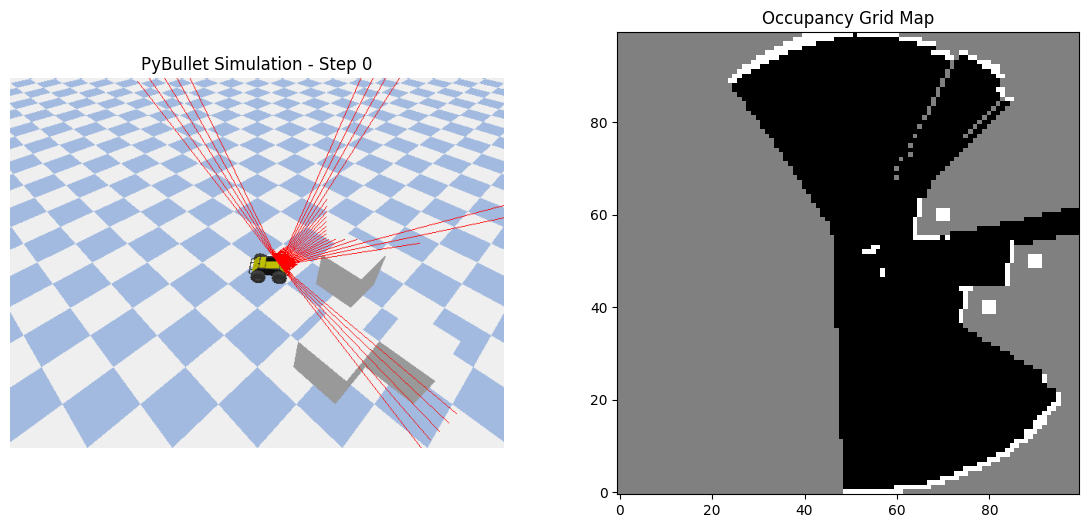

Step: 0
Initial Pose: (0.48661514782395987, -0.03733913837894658, 0.6576356790215241)
Refined Pose: (0.4158482310044698, -0.11021544395300553, 0.5768353073159169)


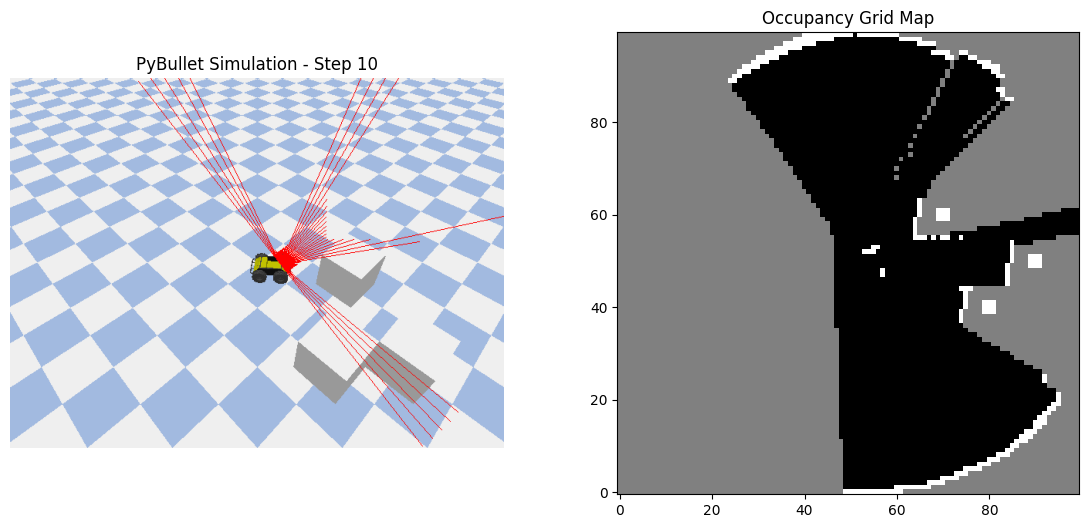

Step: 10
Initial Pose: (0.5118001129824178, -0.016922585296905088, 0.6614302522690599)
Refined Pose: (0.4432469588833403, -0.11408848950700837, 0.7843869249595665)


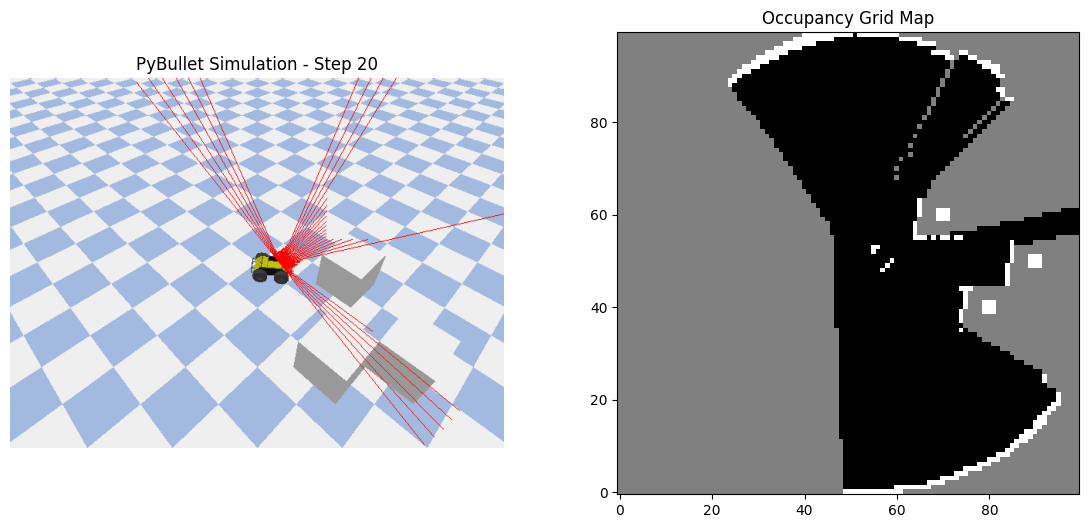

Step: 20
Initial Pose: (0.5136854608554714, -0.021319768265568924, 0.6710355443223835)
Refined Pose: (0.5454486401734766, 0.030794724866880945, 0.6279633823579188)


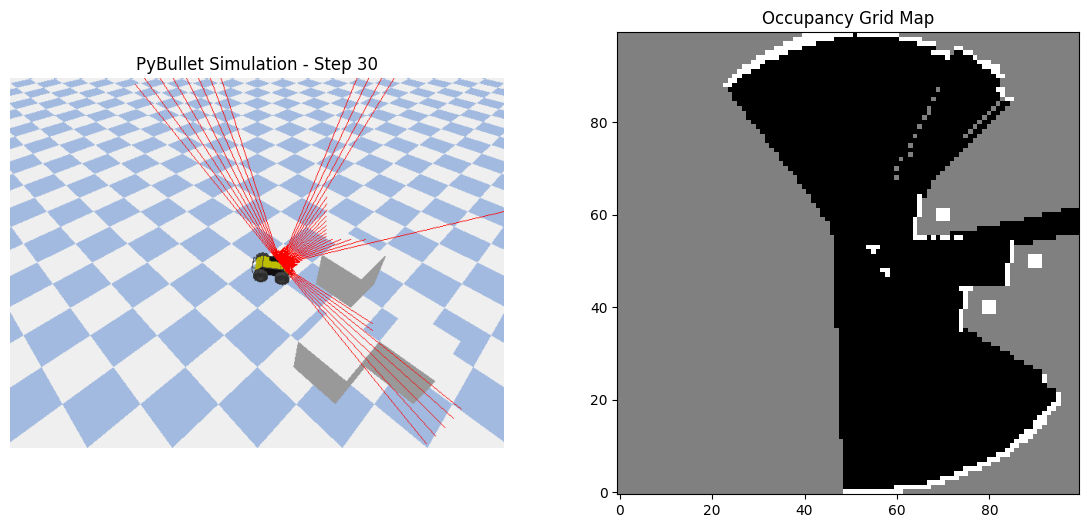

Step: 30
Initial Pose: (0.5154548823411561, -0.024830781511022696, 0.679925441076606)
Refined Pose: (0.5081169199407074, -0.1898167986619241, 0.7423308277691184)


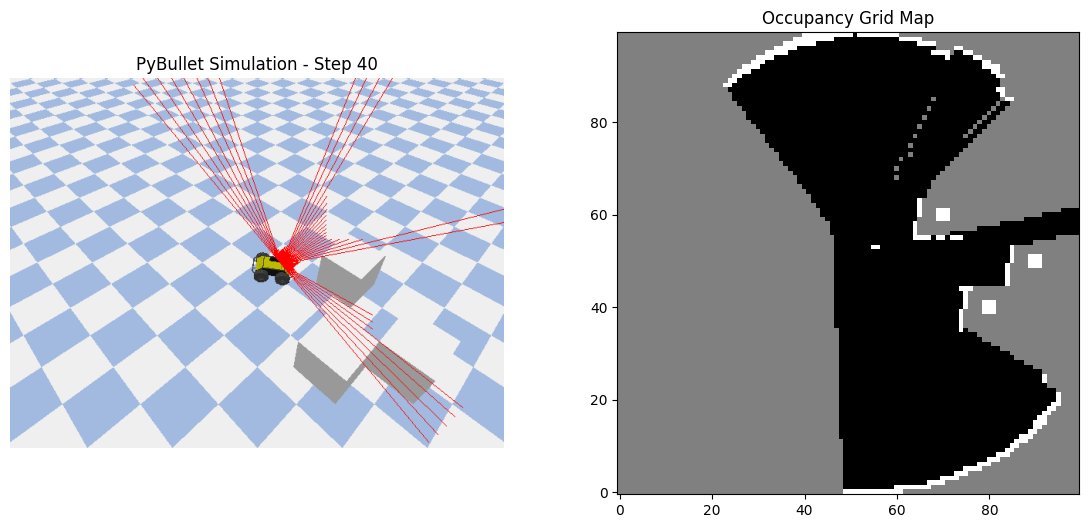

Step: 40
Initial Pose: (0.5205666252347151, -0.02199780245036253, 0.6894897781604852)
Refined Pose: (0.6211251379698242, -0.1297865987546104, 0.831824918392472)


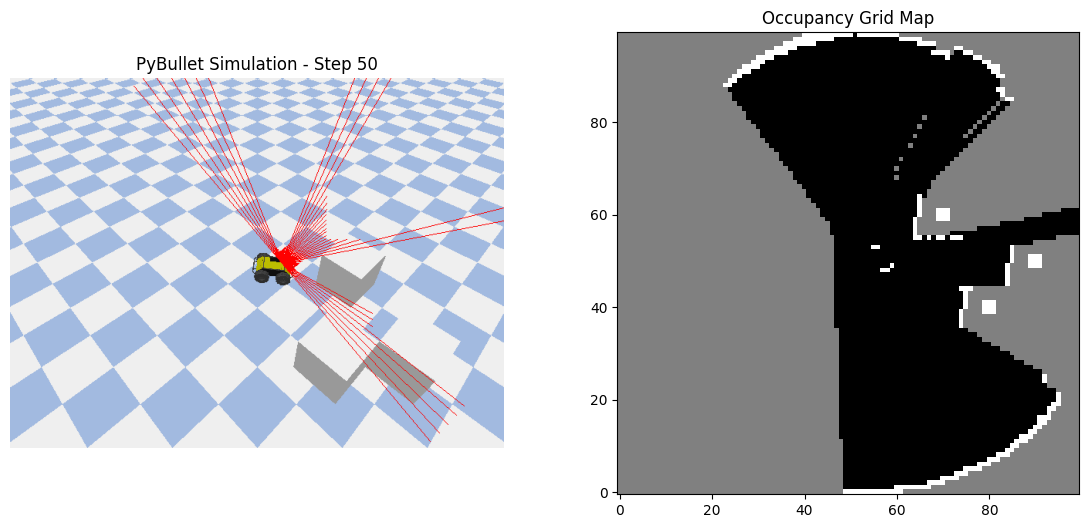

Step: 50
Initial Pose: (0.5381055901022772, -0.01170668069851526, 0.6946639418390748)
Refined Pose: (0.6310958160379336, -0.08320366547968262, 0.7273376109813366)


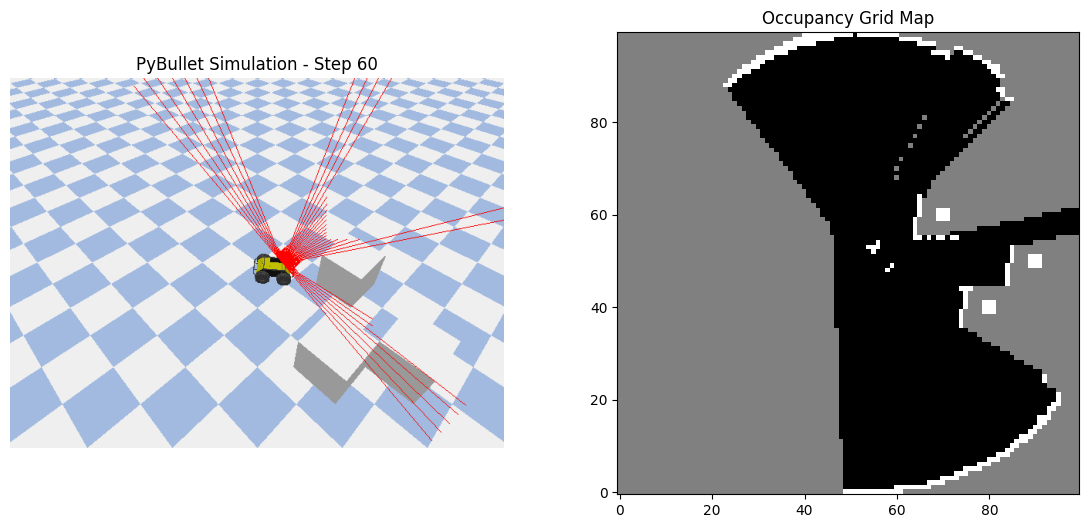

Step: 60
Initial Pose: (0.5594011949389027, -0.004371311323944138, 0.6970260031400876)
Refined Pose: (0.5656920938634235, -0.07978086885596289, 0.6043401574219545)


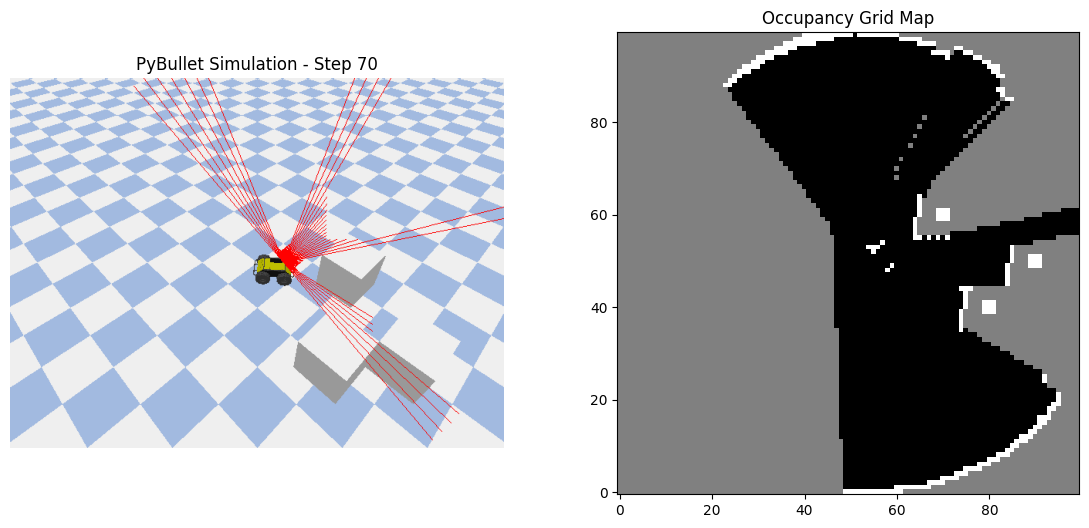

Step: 70
Initial Pose: (0.5741509235397878, 0.0018924198762915495, 0.7008789844371939)
Refined Pose: (0.4957244808485058, -0.08258471724391396, 0.7420121957239875)


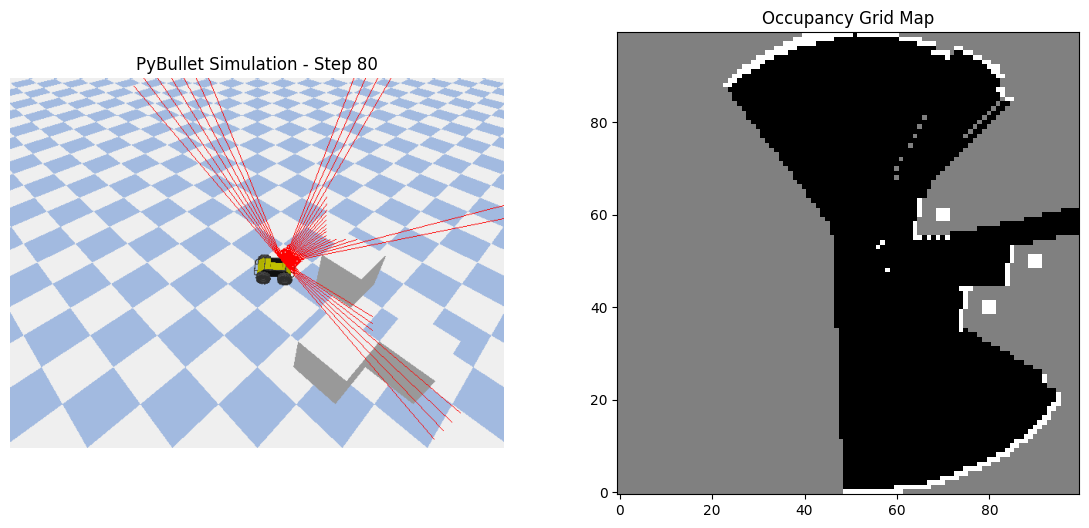

Step: 80
Initial Pose: (0.5826833135800997, 0.006749038854442981, 0.7042348426120855)
Refined Pose: (0.7322451597643589, -0.03617260579060685, 0.7232927464342955)


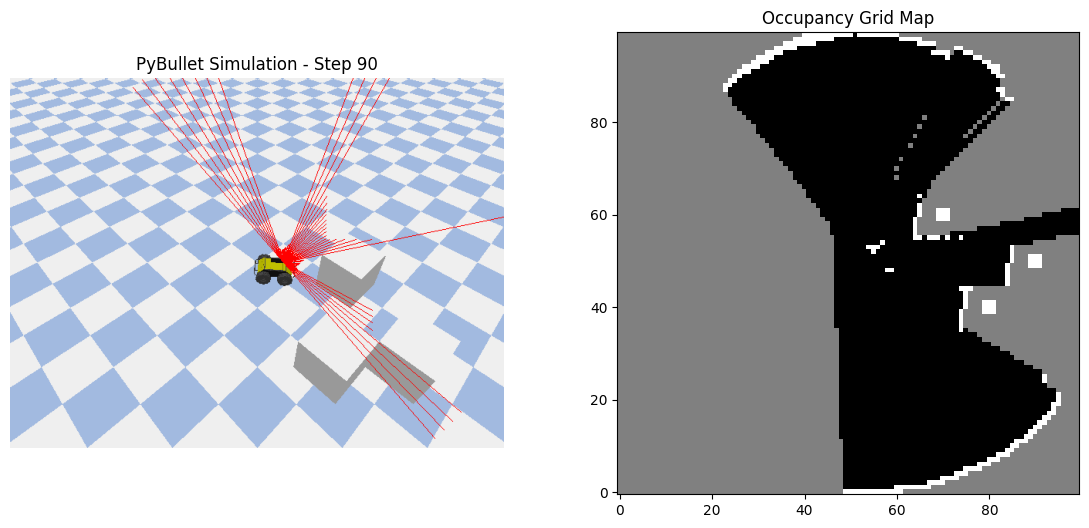

Step: 90
Initial Pose: (0.580658491173553, 0.0020024404619517315, 0.7097181717645009)
Refined Pose: (0.5615009066781456, -0.1339594748646707, 0.7433932779440902)


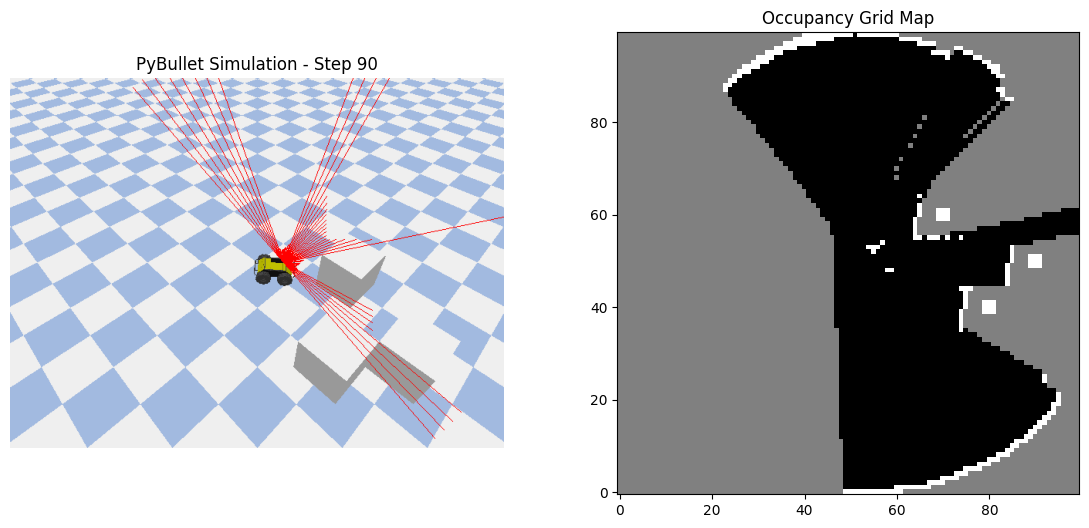

In [ ]:
beam_lines = []
plt.ion()
#plt.figure(figsize=(6, 6))
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
#while True:
for step in range(100):
    p.stepSimulation()

    distances, beam_endpoints, hits, initial_pose = simulate_lidar(robot_id)
    refined_pose = estimate_best_poseB(beam_endpoints, grid_map, initial_pose,distances, beam_based_model)

    # Mark frees and occupied intelligently
    update_map(grid_map, beam_endpoints, refined_pose, hit_max=True)
    pos, _ = p.getBasePositionAndOrientation(robot_id)
    l_speed, r_speed = avoid_obstacles(beam_endpoints, pos)
    drive(robot_id, l_speed, r_speed)

    if step % 10 == 0:
        frame = render_pybullet_with_lidar(robot_id, beam_endpoints)
        axs[0].cla()
        axs[0].imshow(frame)
        axs[0].set_title(f"PyBullet Simulation - Step {step}")
        axs[0].axis("off")
        axs[1].cla()
        axs[1].imshow( grid_map, cmap="gray", origin="lower",vmin=0, vmax=1)
        axs[1].set_title("Occupancy Grid Map")
        display(fig)
        #clear_output(wait=True)
        print("Step:", step)
        print("Initial Pose:", initial_pose)
        print("Refined Pose:", refined_pose)

    time.sleep(1.0 / 240.0)

## Correlation Based

#### Correlation Based DISCRETE Model( discussed as a scan matching)

In [ ]:
def estimate_best_pose(beam_endpoints, map_data, current_pose, correlation_score_func):
    candidates = generate_candidate_poses(current_pose)
    best_score, best_pose = -1, current_pose
    for pose in candidates:
        # Reproject endpoints to the candidate frame by rotating them around the current origin
        # Simpler alternative: treat endpoints as static landmarks and just score cells directly (already done)
        score = correlation_score_func(map_data, beam_endpoints, pose)
        if score > best_score:
            best_score, best_pose = score, pose
    return best_pose

In [ ]:
def correlation_score(map_data, beam_endpoints, robot_pose):
    score = 0
    for xw, yw in beam_endpoints:
        c, r = world_to_map(xw, yw)
        if 0 <= r < MAP_SIZE and 0 <= c < MAP_SIZE:
            score += 1 if map_data[r, c] == 1 else 0
    return score

Step: 90
Initial Pose: (0.41684775212192293, -0.008870219676395338, 0.47079824128183545)
Refined Pose: (0.34565531751400846, -0.038625533602485995, 0.6427250645777101)


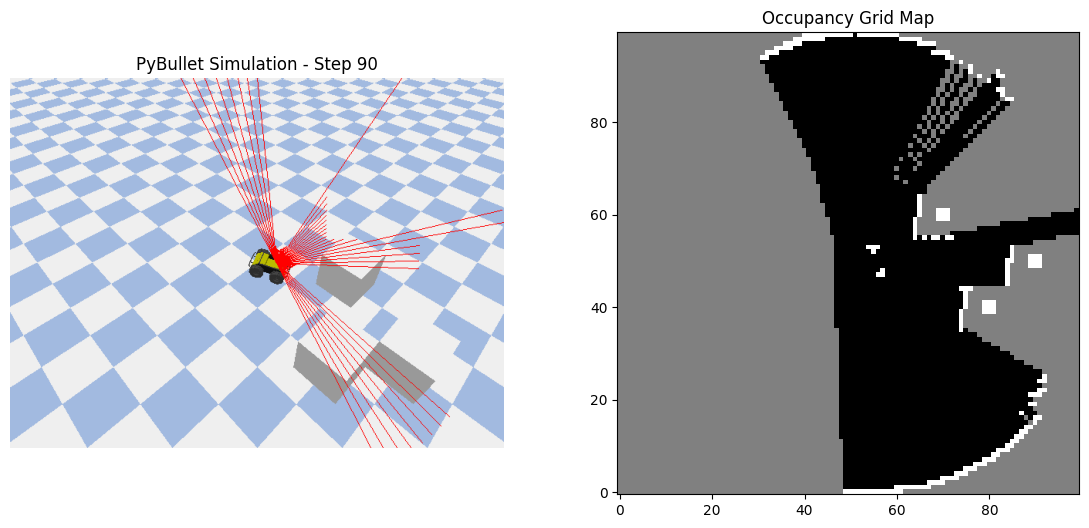

In [ ]:
beam_lines = []
plt.ion()
#plt.figure(figsize=(6, 6))
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
#while True:
for step in range(100):
    p.stepSimulation()

    distances, beam_endpoints, hits, initial_pose = simulate_lidar(robot_id)
    refined_pose = estimate_best_pose(beam_endpoints, grid_map, initial_pose, correlation_score)

    # Mark frees and occupied intelligently
    update_map(grid_map, beam_endpoints, refined_pose, hit_max=True)

    #print("Step\tInitial Pose\tRefined Pose")
    #print(step)
    #print(initial_pose)
    #print(refined_pose)

    pos, _ = p.getBasePositionAndOrientation(robot_id)
    l_speed, r_speed = avoid_obstacles(beam_endpoints, pos)
    drive(robot_id, l_speed, r_speed)

    # Render simulation inside notebook
    # -----------------------------------
    if step % 10 == 0:
        frame = render_pybullet_with_lidar(robot_id,beam_endpoints)
        axs[0].cla()
        axs[0].imshow(frame)
        axs[0].set_title(f"PyBullet Simulation - Step {step}")
        axs[0].axis("off")

        axs[1].cla()
        axs[1].imshow(grid_map, cmap="gray", origin="lower",  vmin=0, vmax=1)
        axs[1].set_title("Occupancy Grid Map")

        display(fig)
        clear_output(wait=True)

        print("Step:", step)
        print("Initial Pose:", initial_pose)
        print("Refined Pose:", refined_pose)

    time.sleep(1.0 / 240.0)

#### Correlation Based Probabilistic Measurement Model
(Suited When assumptions of Independent Beams is not the scenario)

In [ ]:
def correlation_scoreA(map_data, beam_endpoints, robot_pose):
    diffs = []
    for xw, yw in beam_endpoints:
        c, r = world_to_map(xw, yw)
        if 0 <= r < MAP_SIZE and 0 <= c < MAP_SIZE:
            # convert occupancy to soft measurement
            obs = 1.0 if map_data[r, c] == 1 else 0.0
            # expected value (same map-based expectation)
            expected = obs
        else:
            obs = 0.0
            expected = 0.0
        # residual per beam
        diffs.append(obs - expected)
    diffs = np.array(diffs)
    # correlation between beams (off-diagonal coupling)
    n = len(diffs)
    Sigma = np.full((n, n), 0.3)
    np.fill_diagonal(Sigma, 1.0)
    # Mahalanobis-style correlation score
    score = np.exp(-0.5 * diffs.T @ np.linalg.inv(Sigma) @ diffs)
   #print(Sigma)
    #print("Correlation Score: ",score)
    return float(score)

Step: 90
Initial Pose: (0.1252231261984993, 0.01600136182216538, 0.12893028919872182)
Refined Pose: (0.1058814075068591, -0.07864685710912139, 0.06183592070129568)


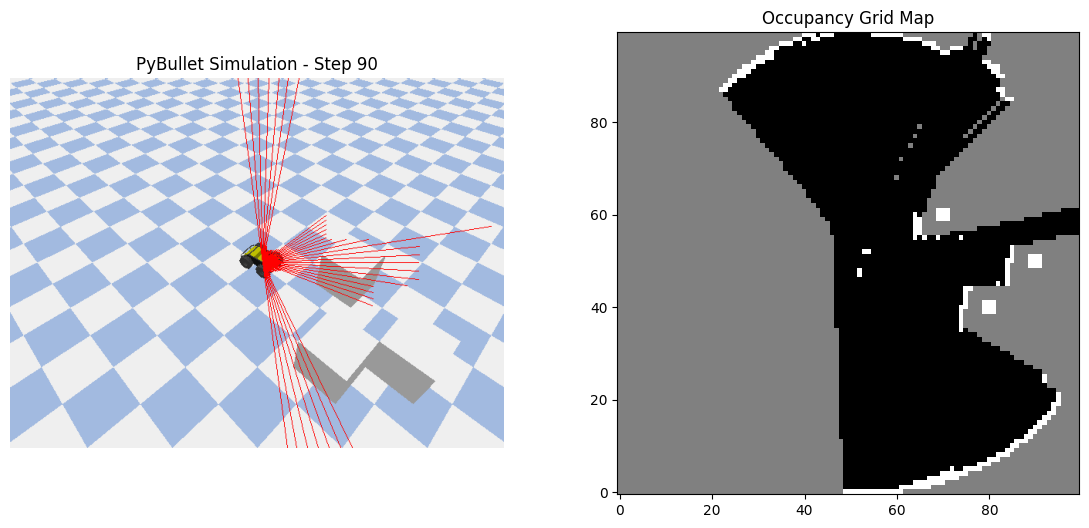

In [ ]:
beam_lines = []
plt.ion()
#plt.figure(figsize=(6, 6))
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
#while True:
for step in range(100):
    p.stepSimulation()

    distances, beam_endpoints, hits, initial_pose = simulate_lidar(robot_id)
    refined_pose = estimate_best_pose(beam_endpoints, grid_map, initial_pose, correlation_scoreA)

    # Mark frees and occupied intelligently
    update_map(grid_map, beam_endpoints, refined_pose, hit_max=True)

    #print("Step\tInitial Pose\tRefined Pose")
    #print(step)
    #print(initial_pose)
    #print(refined_pose)

    pos, _ = p.getBasePositionAndOrientation(robot_id)
    l_speed, r_speed = avoid_obstacles(beam_endpoints, pos)
    drive(robot_id, l_speed, r_speed)

    # Render simulation inside notebook
    # -----------------------------------
    if step % 10 == 0:
        frame = render_pybullet_with_lidar(robot_id,beam_endpoints)
        axs[0].cla()
        axs[0].imshow(frame)
        axs[0].set_title(f"PyBullet Simulation - Step {step}")
        axs[0].axis("off")

        axs[1].cla()
        axs[1].imshow(grid_map, cmap="gray", origin="lower",  vmin=0, vmax=1)
        axs[1].set_title("Occupancy Grid Map")

        display(fig)
        clear_output(wait=True)

        print("Step:", step)
        print("Initial Pose:", initial_pose)
        print("Refined Pose:", refined_pose)

    time.sleep(1.0 / 240.0)

## Likelihood Based Model

#### Likelihood model

In [ ]:
def gaussian(x, mu, sigma):
    return np.exp(-0.5 * ((x - mu) / sigma) ** 2)

In [ ]:
from scipy.ndimage import distance_transform_edt

def build_likelihood_field(map_data):
    occupied = map_data > 0.7
    distance_map = distance_transform_edt(~occupied)
    return distance_map * MAP_RESOLUTION

In [ ]:
def likelihood_field_model(distance_field,beam_endpoints,sigma=0.3):
    score = 0.0
    for xw, yw in beam_endpoints:
        c, r = world_to_map(xw, yw)
        if 0 <= r < MAP_SIZE and 0 <= c < MAP_SIZE:
            dist = distance_field[r, c]
            score += np.log(gaussian(dist, 0, sigma) + 1e-9)
    return score

In [ ]:
distance_field = build_likelihood_field(grid_map)
print(distance_field)

[[8.81022134 8.72066511 8.63133825 ... 4.21544778 4.25440948 4.29534632]
 [8.76641318 8.67640479 8.58661749 ... 4.12310563 4.16293166 4.20475921]
 [8.7235314  8.63307593 8.54283325 ... 4.03112887 4.07185461 4.11460812]
 ...
 [7.78267306 7.69415362 7.60591875 ... 4.44072066 4.5        4.5607017 ]
 [7.82943165 7.74144689 7.65375725 ... 4.52216762 4.580393   4.6400431 ]
 [7.87718224 7.78973684 7.70259696 ... 4.60434577 4.66154481 4.72016949]]


In [ ]:
def estimate_best_poseL(beam_endpoints, map_data, current_pose, likelihood_field_model):
    candidates = generate_candidate_poses(current_pose)
    best_score, best_pose = -1, current_pose
    for pose in candidates:
        score = likelihood_field_model(distance_field, beam_endpoints)
        if score > best_score:
            best_score, best_pose = score, pose
    return best_pose

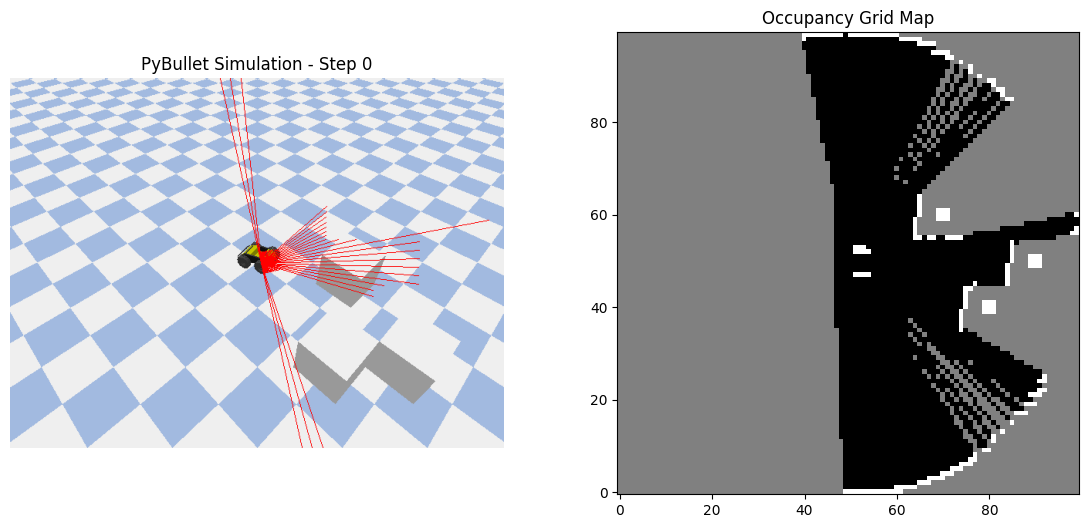

Step: 0
Initial Pose: (0.0916865231980395, -0.004515041075886759, 0.21470304519586209)
Refined Pose: (0.0916865231980395, -0.004515041075886759, 0.21470304519586209)


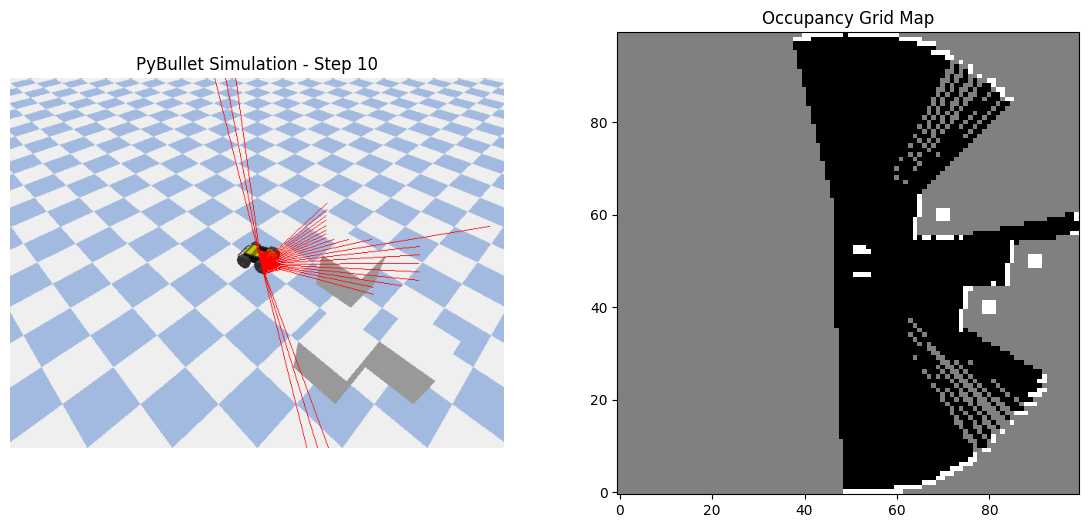

Step: 10
Initial Pose: (0.09470305714876216, -0.018970076716226424, 0.24199346292753984)
Refined Pose: (0.09470305714876216, -0.018970076716226424, 0.24199346292753984)


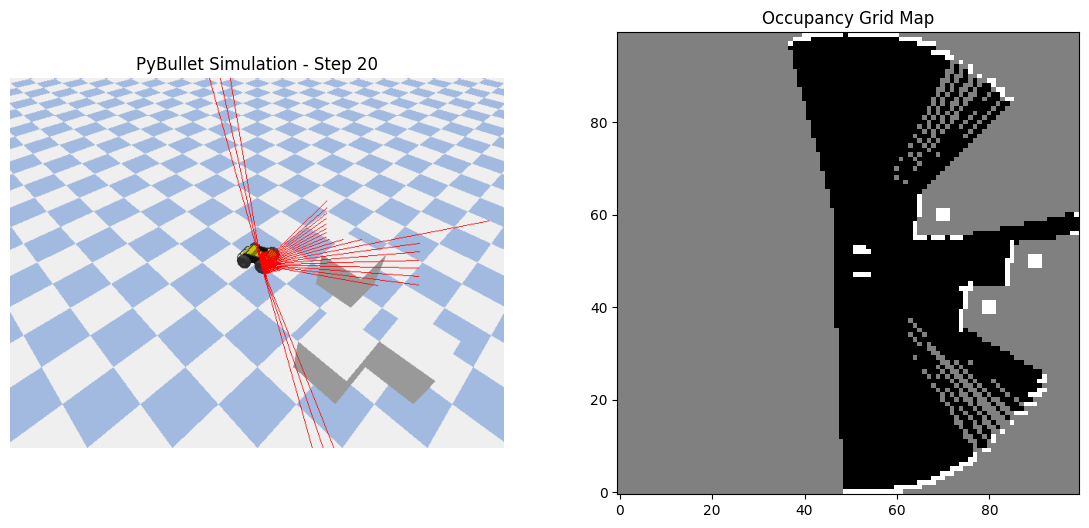

Step: 20
Initial Pose: (0.09791372686515509, -0.03348370809374283, 0.26886919456243563)
Refined Pose: (0.09791372686515509, -0.03348370809374283, 0.26886919456243563)


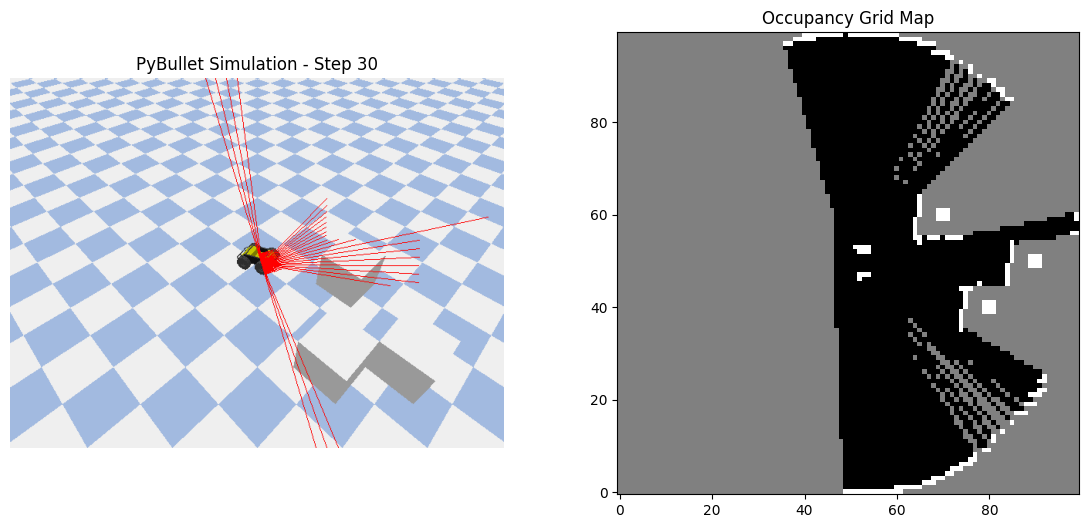

Step: 30
Initial Pose: (0.1005918284959813, -0.04244270723103237, 0.28902779021773856)
Refined Pose: (0.1005918284959813, -0.04244270723103237, 0.28902779021773856)


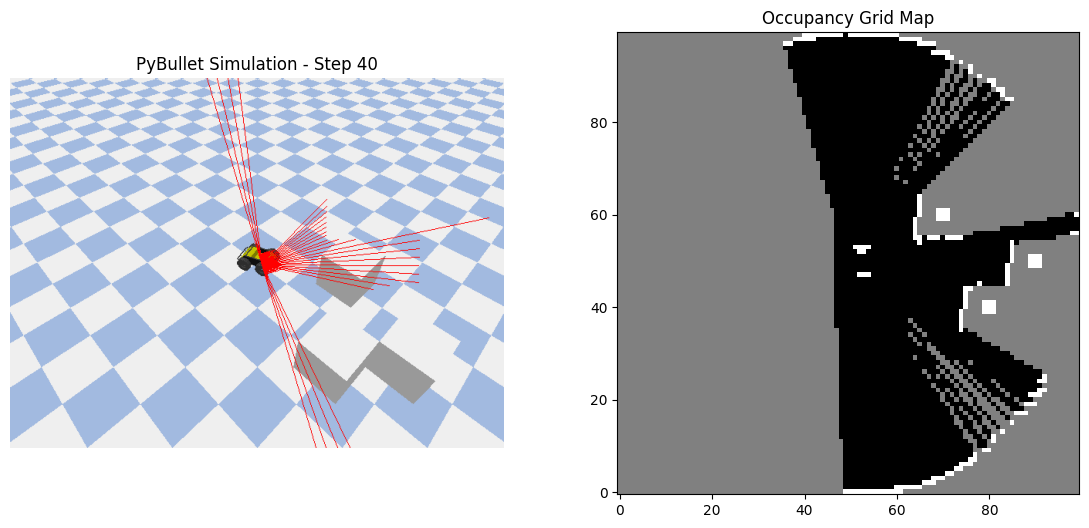

Step: 40
Initial Pose: (0.1047403127050494, -0.03387753449347265, 0.2845273523952491)
Refined Pose: (0.1047403127050494, -0.03387753449347265, 0.2845273523952491)


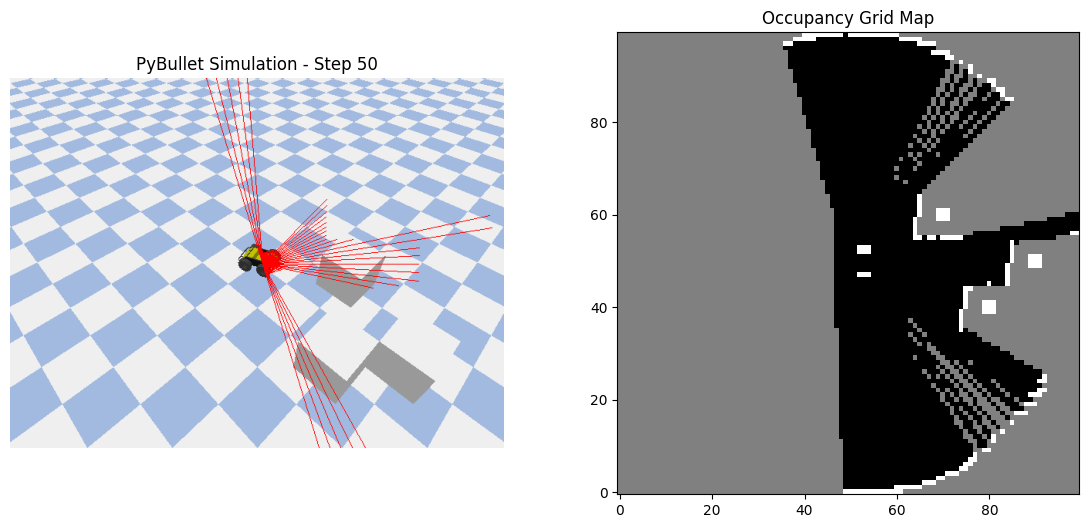

Step: 50
Initial Pose: (0.13008839098310013, -0.02752647683480407, 0.2924711347430833)
Refined Pose: (0.13008839098310013, -0.02752647683480407, 0.2924711347430833)


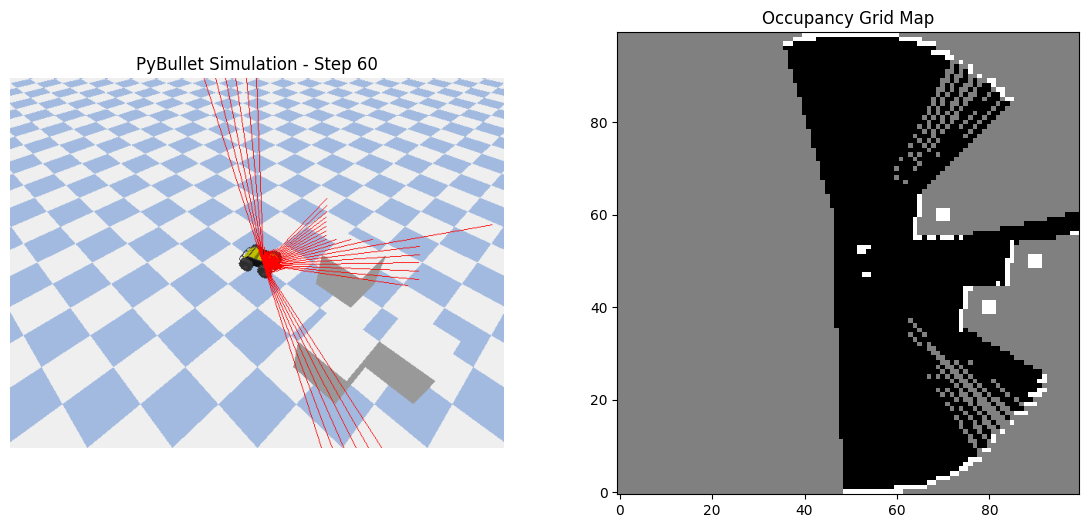

Step: 60
Initial Pose: (0.14673278383599797, -0.035310709827997805, 0.30465762695706006)
Refined Pose: (0.14673278383599797, -0.035310709827997805, 0.30465762695706006)


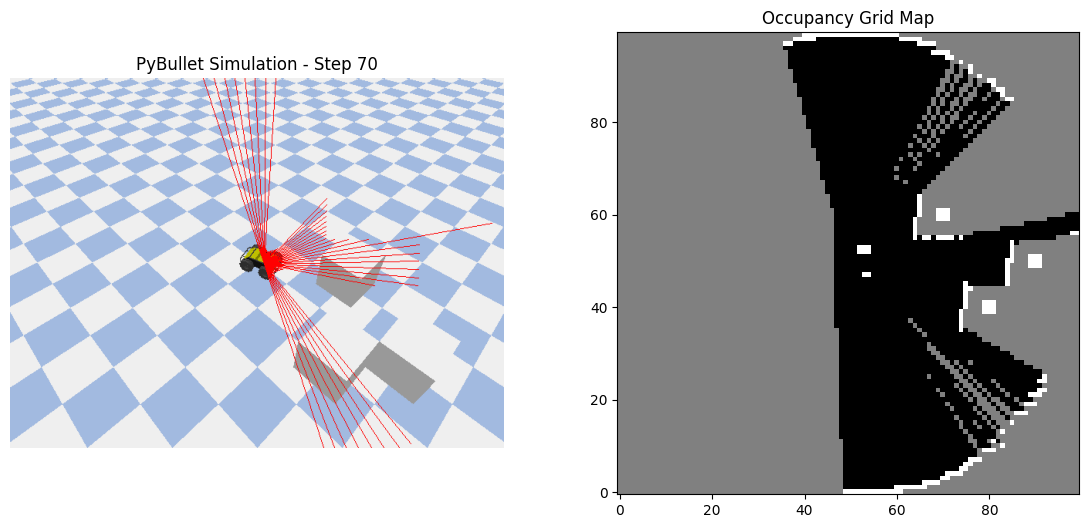

Step: 70
Initial Pose: (0.15969748445661086, -0.03256156172035632, 0.31267558238301185)
Refined Pose: (0.15969748445661086, -0.03256156172035632, 0.31267558238301185)


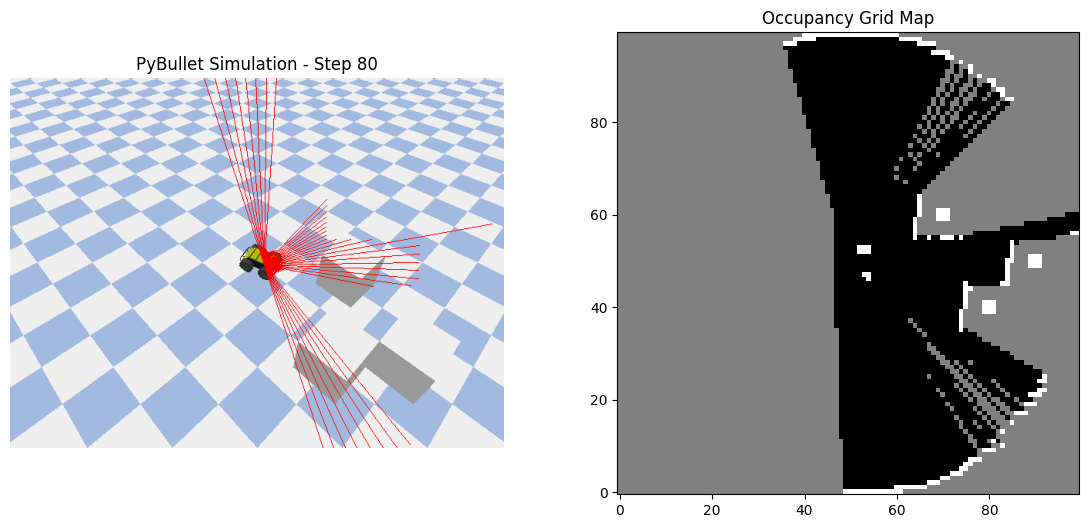

Step: 80
Initial Pose: (0.15727287588342492, -0.04134261476567088, 0.30899849605569135)
Refined Pose: (0.15727287588342492, -0.04134261476567088, 0.30899849605569135)


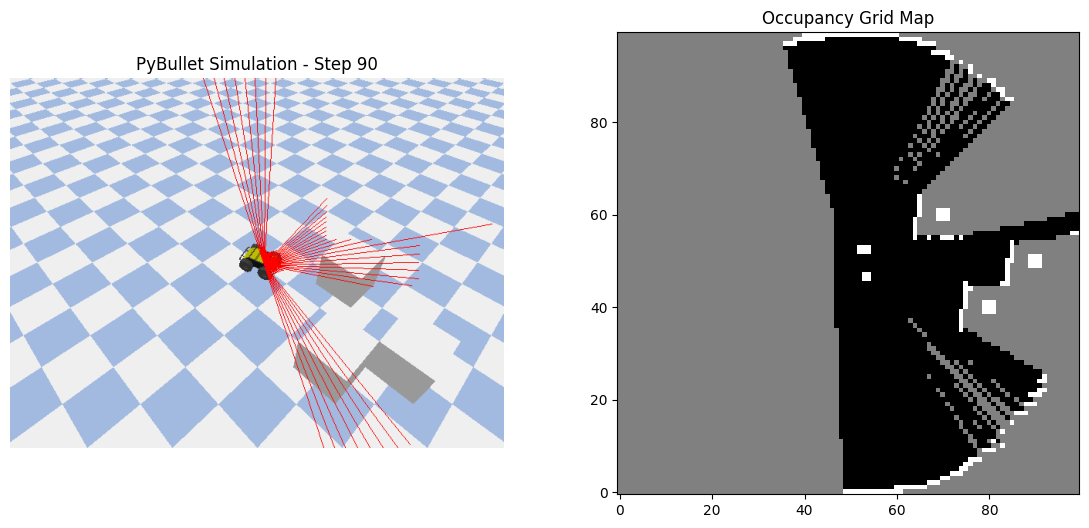

Step: 90
Initial Pose: (0.15090624383563503, -0.04764167202785083, 0.31173048978380263)
Refined Pose: (0.15090624383563503, -0.04764167202785083, 0.31173048978380263)


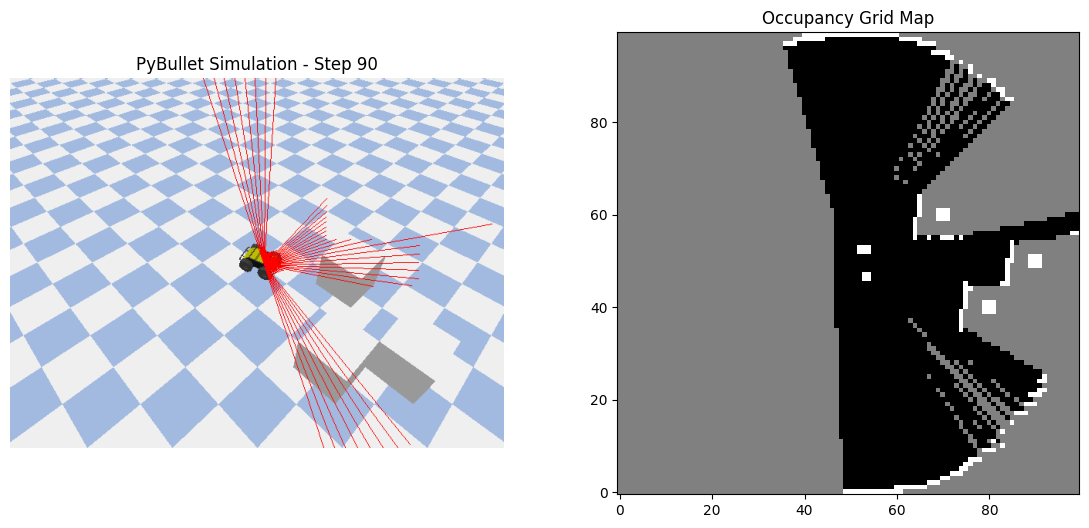

In [ ]:
beam_lines = []
plt.ion()
#plt.figure(figsize=(6, 6))
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
#while True:
for step in range(100):
    p.stepSimulation()

    distances, beam_endpoints, hits, initial_pose = simulate_lidar(robot_id)
    refined_pose = estimate_best_poseL(beam_endpoints, grid_map, initial_pose, likelihood_field_model)

    # Mark frees and occupied intelligently
    update_map(grid_map, beam_endpoints, refined_pose, hit_max=True)

    #print("Step\tInitial Pose\tRefined Pose")
    #print(step)
    #print(initial_pose)
    #print(refined_pose)

    pos, _ = p.getBasePositionAndOrientation(robot_id)
    l_speed, r_speed = avoid_obstacles(beam_endpoints, pos)
    drive(robot_id, l_speed, r_speed)

    if step % 10 == 0:
        frame = render_pybullet_with_lidar(robot_id, beam_endpoints)
        axs[0].cla()
        axs[0].imshow(frame)
        axs[0].set_title(f"PyBullet Simulation - Step {step}")
        axs[0].axis("off")
        axs[1].cla()
        axs[1].imshow( grid_map, cmap="gray", origin="lower",vmin=0, vmax=1)
        axs[1].set_title("Occupancy Grid Map")
        display(fig)
        #clear_output(wait=True)
        print("Step:", step)
        print("Initial Pose:", initial_pose)
        print("Refined Pose:", refined_pose)

    time.sleep(1.0 / 240.0)

## Feature Based Model

### Feature Creation

In [ ]:
landmarks = np.array(obstacles)

### Model

In [ ]:
def feature_based_model(observed_features,known_landmarks, pose, sigma=100.5):
    score = 0.0
    for fx, fy in observed_features:
        dists = np.linalg.norm(known_landmarks - np.array([fx, fy]), axis=1)
        nearest = np.min(dists)
        score += np.log(gaussian(nearest, 0, sigma) + 1e-9)
    return score

In [ ]:
import numpy as np
from sklearn.cluster import DBSCAN

def extract_observed_features(beam_endpoints, eps=0.3, min_samples=3):
    X = np.array(beam_endpoints)
    clustering = DBSCAN(eps=eps, min_samples=min_samples).fit(X)
    labels = clustering.labels_
    observed_features = []
    for label in set(labels):
        if label == -1:
            continue  # ignore noise
        cluster_points = X[labels == label]
        centroid = cluster_points.mean(axis=0)
        observed_features.append(centroid)
    return np.array(observed_features)

In [ ]:
def estimate_best_poseF(beam_endpoints, map_data, current_pose, feature_based_model):
    candidates = generate_candidate_poses(current_pose)
    best_score, best_pose = -1, current_pose
    for pose in candidates:
        #observed_features = beam_endpoints[::10]
        observed_features = extract_observed_features(beam_endpoints)
        score = feature_based_model(observed_features,landmarks, pose)
        if score > best_score:
            best_score, best_pose = score, pose
    return best_pose

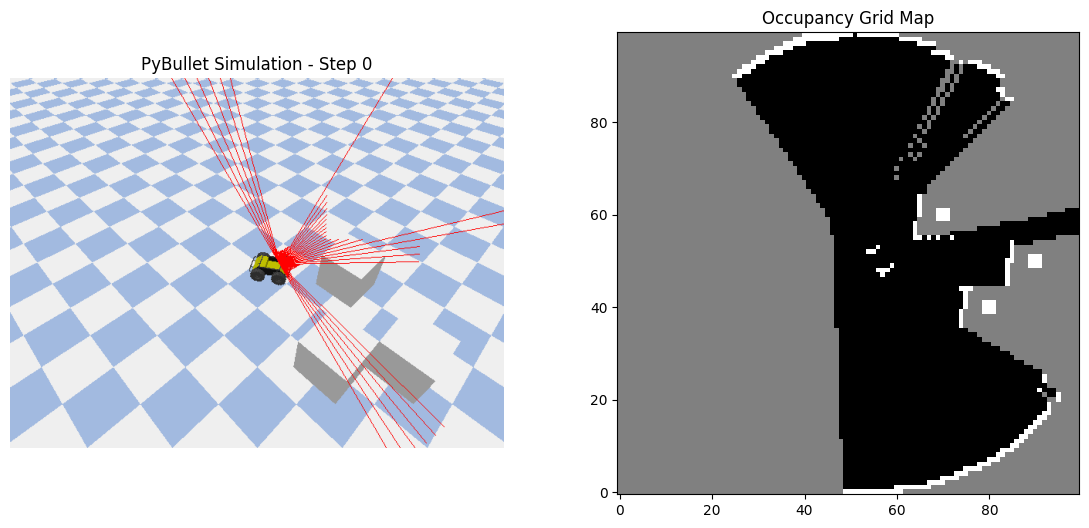

Step: 0
Initial Pose: (0.49606756868176616, -0.020683728152547855, 0.5233658340701498)
Refined Pose: (0.35327075643283334, 0.14883126068679217, 0.690036539345958)


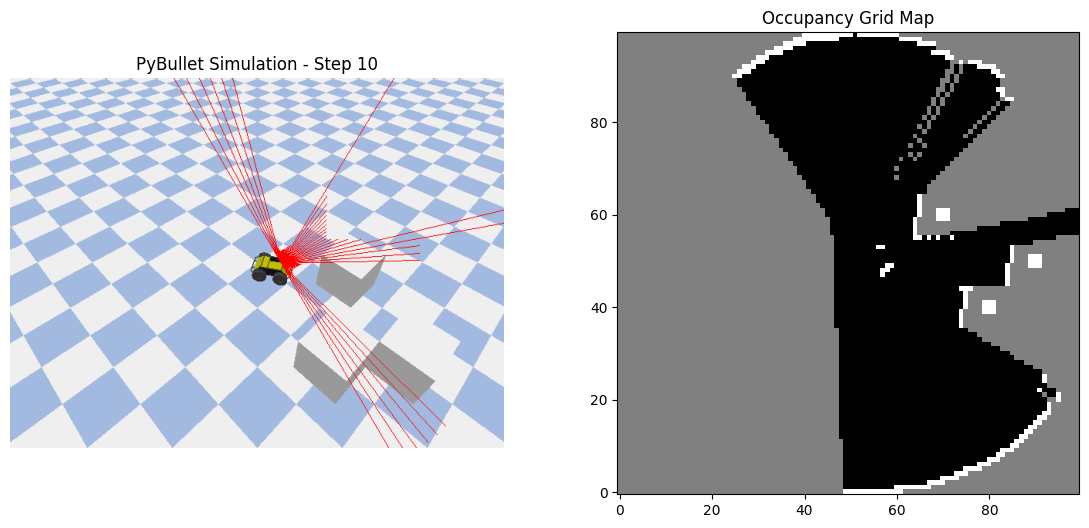

Step: 10
Initial Pose: (0.5283022735405273, -0.0020421329907239724, 0.5234814766916159)
Refined Pose: (0.536459066012795, 0.10829812344808654, 0.6533511107059294)


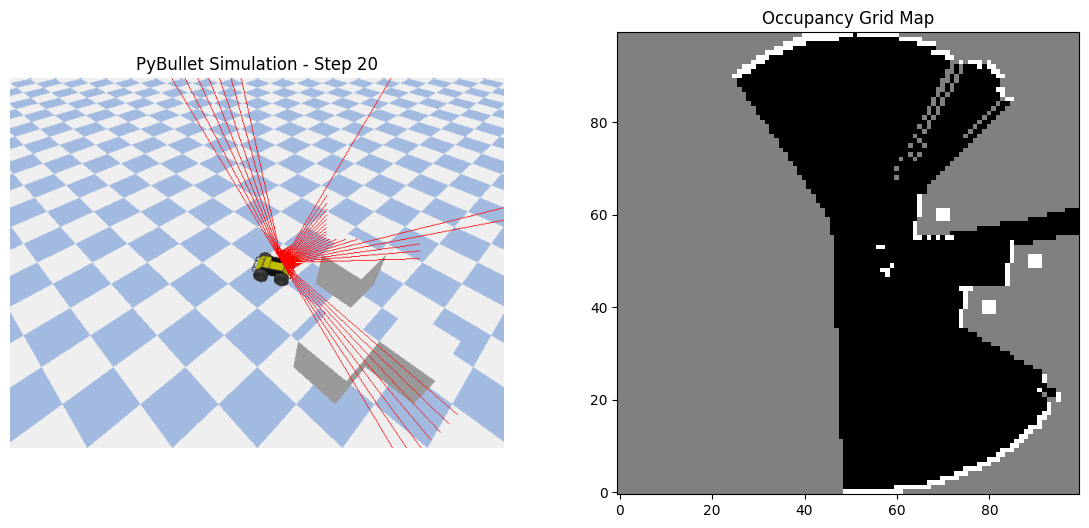

Step: 20
Initial Pose: (0.5475440946609481, 0.006681907240682438, 0.5354485847340011)
Refined Pose: (0.6258525207087375, 0.044017087785048765, 0.6231937444258028)


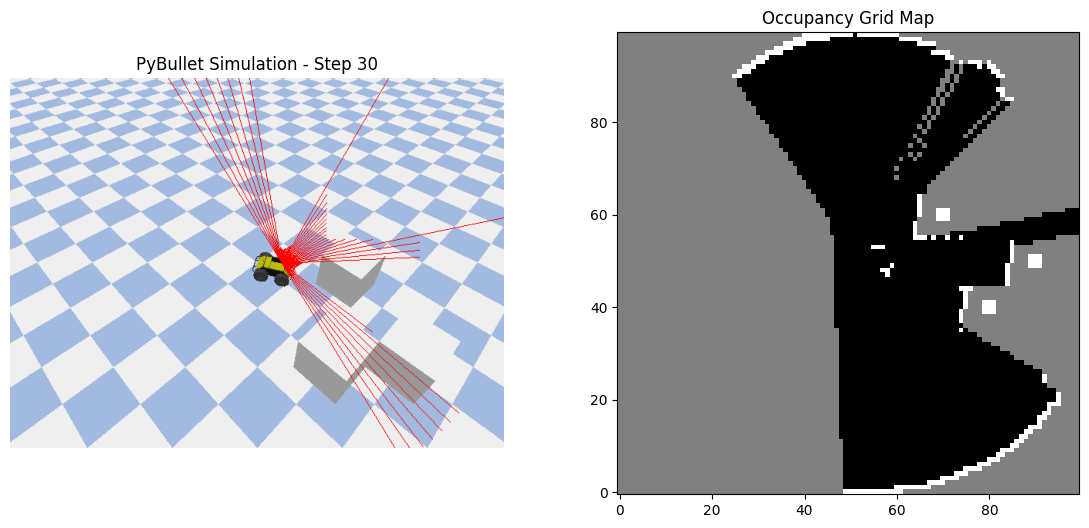

Step: 30
Initial Pose: (0.5488656218831698, -0.003360288959367421, 0.5466701095765817)
Refined Pose: (0.4287566938135925, 0.061483020306014866, 0.5993831390718598)


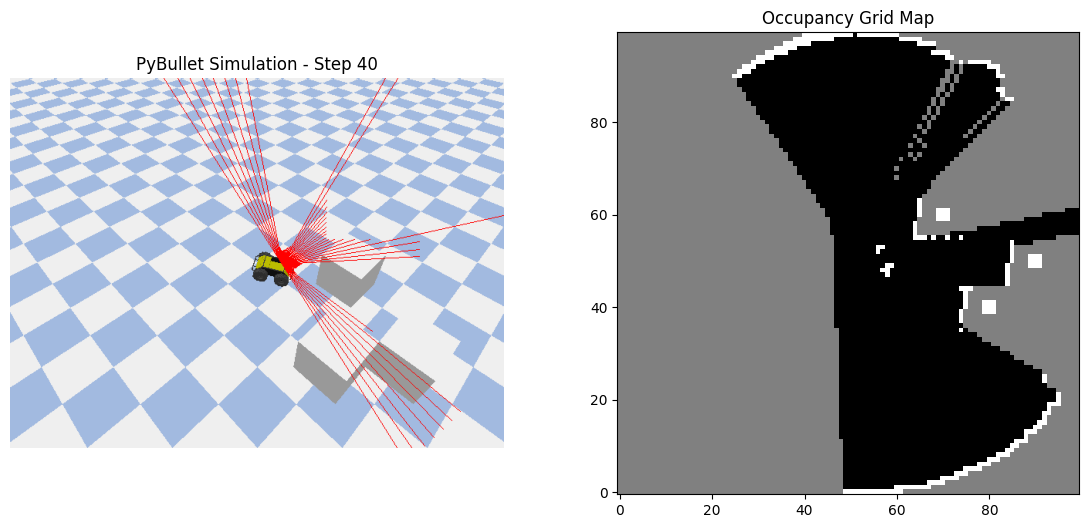

Step: 40
Initial Pose: (0.534548573343701, -0.021790496276674117, 0.5604662302897649)
Refined Pose: (0.5255450776506202, 0.12031503310393177, 0.6046395178198277)


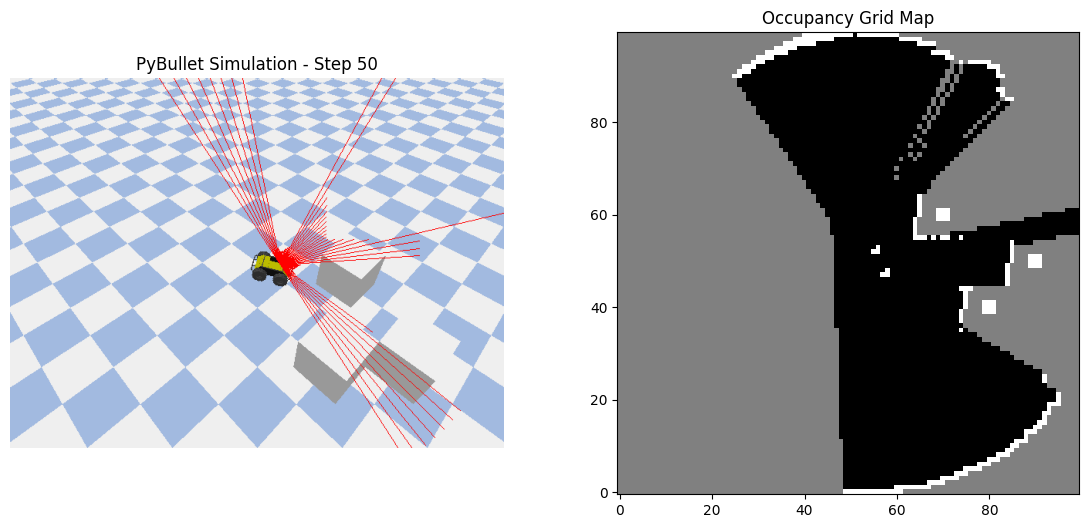

Step: 50
Initial Pose: (0.5102023736662047, -0.042944682176993966, 0.5708992656404136)
Refined Pose: (0.5407197671478696, -0.02969875422872193, 0.566669342360473)


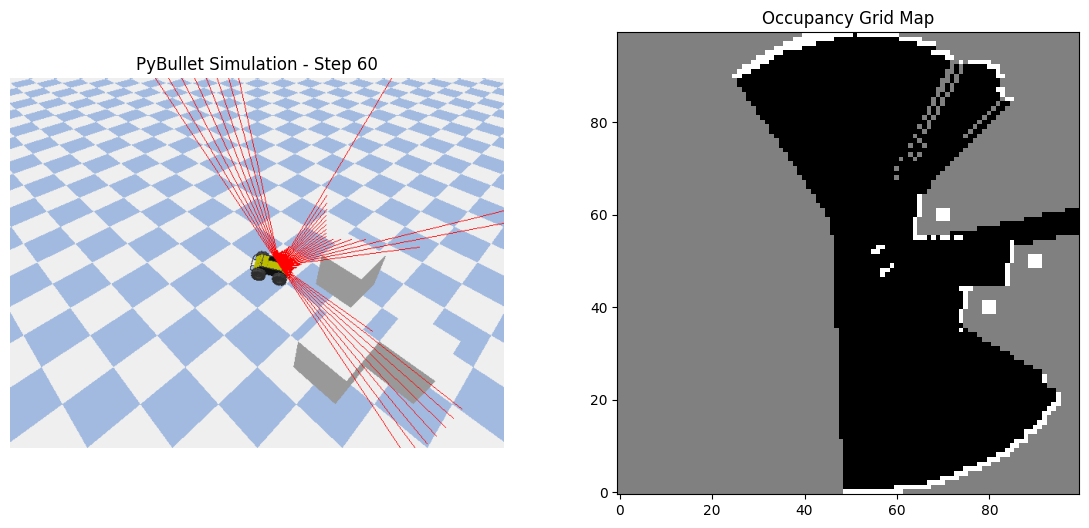

Step: 60
Initial Pose: (0.49233525811963724, -0.05465294617028776, 0.5834938860025095)
Refined Pose: (0.4483008171675383, 0.034563977001722875, 0.7449539257472322)


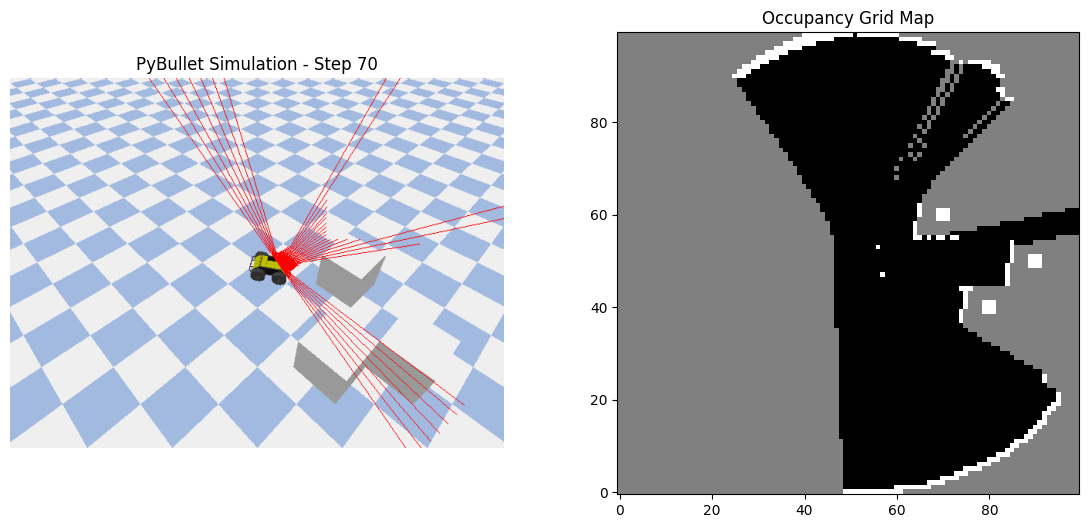

Step: 70
Initial Pose: (0.4850837966583163, -0.05728660067482465, 0.6038637369122392)
Refined Pose: (0.6260069680087595, -0.10529102881950601, 0.5011163407939261)


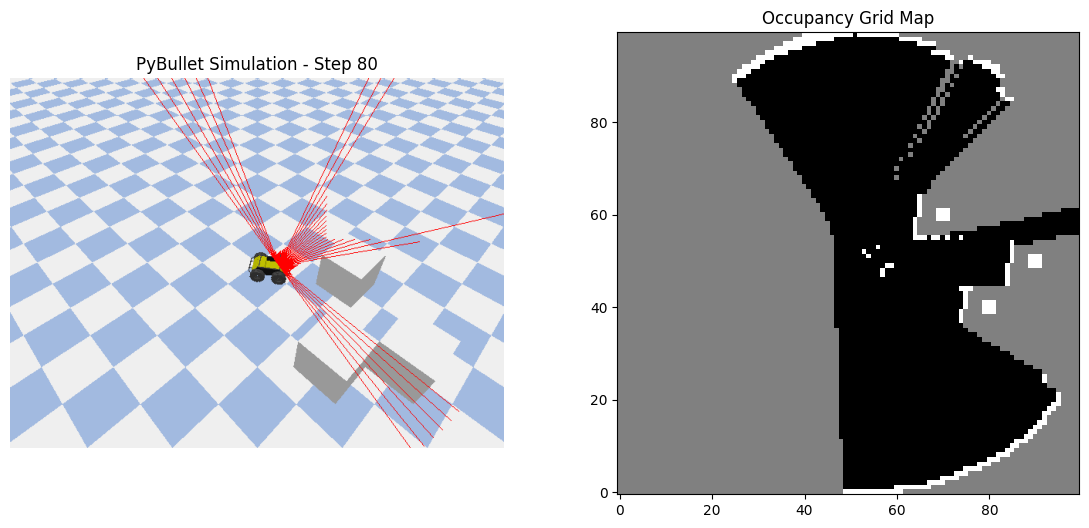

Step: 80
Initial Pose: (0.4774835332325326, -0.05963737677931523, 0.6242311379467064)
Refined Pose: (0.6736025438112887, 0.11559387794575245, 0.7740595527529105)


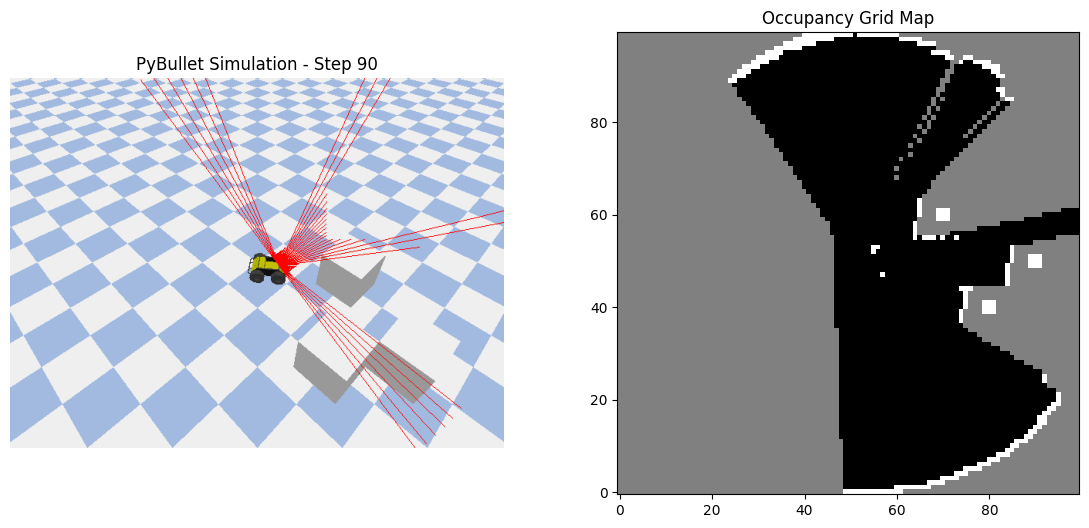

Step: 90
Initial Pose: (0.470375147446097, -0.0574982761927172, 0.6385085252124159)
Refined Pose: (0.6408741657050756, -0.18147228502137658, 0.7894871237243289)


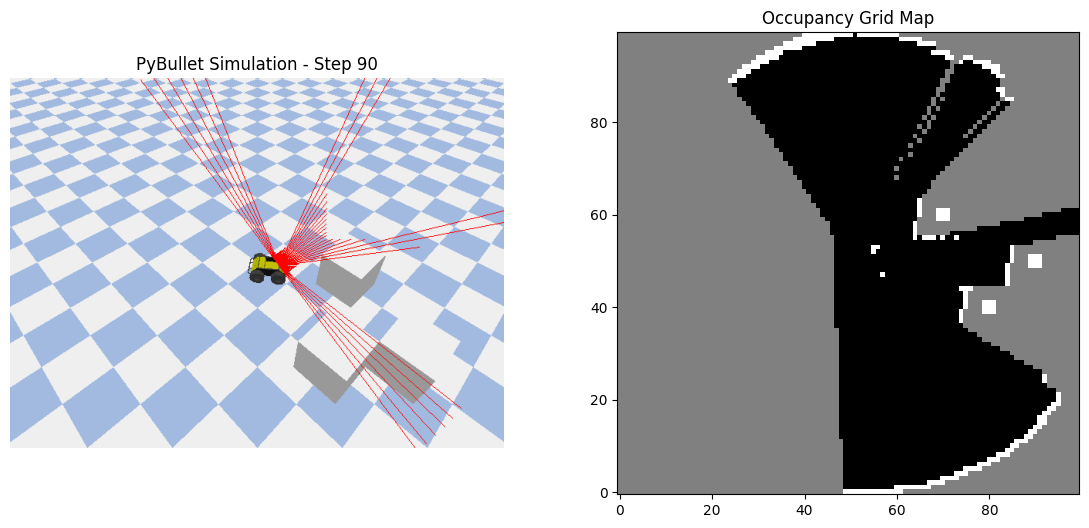

In [ ]:
beam_lines = []
plt.ion()
#plt.figure(figsize=(6, 6))
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
#while True:
for step in range(100):
    p.stepSimulation()

    distances, beam_endpoints, hits, initial_pose = simulate_lidar(robot_id)
    refined_pose = estimate_best_poseF(beam_endpoints, grid_map, initial_pose, feature_based_model)

    # Mark frees and occupied intelligently
    update_map(grid_map, beam_endpoints, refined_pose, hit_max=True)
    pos, _ = p.getBasePositionAndOrientation(robot_id)
    l_speed, r_speed = avoid_obstacles(beam_endpoints, pos)
    drive(robot_id, l_speed, r_speed)

    if step % 10 == 0:
        frame = render_pybullet_with_lidar(robot_id, beam_endpoints)
        axs[0].cla()
        axs[0].imshow(frame)
        axs[0].set_title(f"PyBullet Simulation - Step {step}")
        axs[0].axis("off")
        axs[1].cla()
        axs[1].imshow( grid_map, cmap="gray", origin="lower",vmin=0, vmax=1)
        axs[1].set_title("Occupancy Grid Map")
        display(fig)
        #clear_output(wait=True)
        print("Step:", step)
        print("Initial Pose:", initial_pose)
        print("Refined Pose:", refined_pose)

    time.sleep(1.0 / 240.0)

## Sample Usecase : DNN

### Generate Data - Replace this with real noisy data

In [ ]:
def generate_dnn_dataset(robot_id, steps=200):
    X = []
    y = []
    for _ in range(steps):
        p.stepSimulation()
        distances, beam_endpoints, hits, true_pose = simulate_lidar(robot_id)
        X.append(np.concatenate([true_pose,np.array(distances)]))
        y.append(1)
        for _ in range(3):
            noisy_pose = (true_pose[0] + np.random.normal(0, 0.3),true_pose[1] + np.random.normal(0, 0.3),true_pose[2] + np.random.normal(0, 0.2))
            fake_distances = []
            for i in range(len(distances)):
                angle = noisy_pose[2] + (-np.pi/2 + i*(np.pi/len(distances)))
                fake_dist = expected_distance(grid_map,noisy_pose,angle)
                fake_distances.append(fake_dist)
            X.append(np.concatenate([noisy_pose,np.array(fake_distances)]))
            y.append(0)
    return np.array(X), np.array(y)

In [ ]:
import torch
import torch.nn as nn

class BeamNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

In [ ]:
def train_model(X, y):

    device = "cuda" if torch.cuda.is_available() else "cpu"

    X = torch.tensor(X, dtype=torch.float32).to(device)
    y = torch.tensor(y, dtype=torch.float32).unsqueeze(1).to(device)

    model = BeamNet(X.shape[1]).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = nn.BCELoss()

    for epoch in range(10):

        pred = model(X)
        loss = loss_fn(pred, y)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

    return model

In [ ]:
X, y = generate_dnn_dataset(robot_id, steps=200)
input_dim = X.shape[1]
model = BeamNet(input_dim)
model = train_model(X, y)

Epoch 0, Loss: 0.8006
Epoch 1, Loss: 0.6531
Epoch 2, Loss: 0.5505
Epoch 3, Loss: 0.4814
Epoch 4, Loss: 0.4338
Epoch 5, Loss: 0.4002
Epoch 6, Loss: 0.3744
Epoch 7, Loss: 0.3533
Epoch 8, Loss: 0.3347
Epoch 9, Loss: 0.3165


In [ ]:
def dnn_sensor_model(model, pose, distances):
    x = np.concatenate([pose, distances])
    x = torch.tensor(x, dtype=torch.float32)
    with torch.no_grad():
        score = model(x).item()
    return score

In [ ]:
def estimate_best_poseN(beam_endpoints, map_data, current_pose,measured_distances, dnn_sensor_model):
    candidates = generate_candidate_poses(current_pose)
    best_score, best_pose = -1, current_pose
    for pose in candidates:
        # recompute expected distances for candidate pose
        fake_distances = []
        for i in range(len(distances)):
            angle = pose[2] + (-np.pi/2 + i * (np.pi / len(distances)))
            d = expected_distance(map_data, pose, angle)
            fake_distances.append(d)
        fake_distances = np.array(fake_distances)
        score = dnn_sensor_model(model, pose, fake_distances)
        if score > best_score:
            best_score = score
            best_pose = pose
    return best_pose

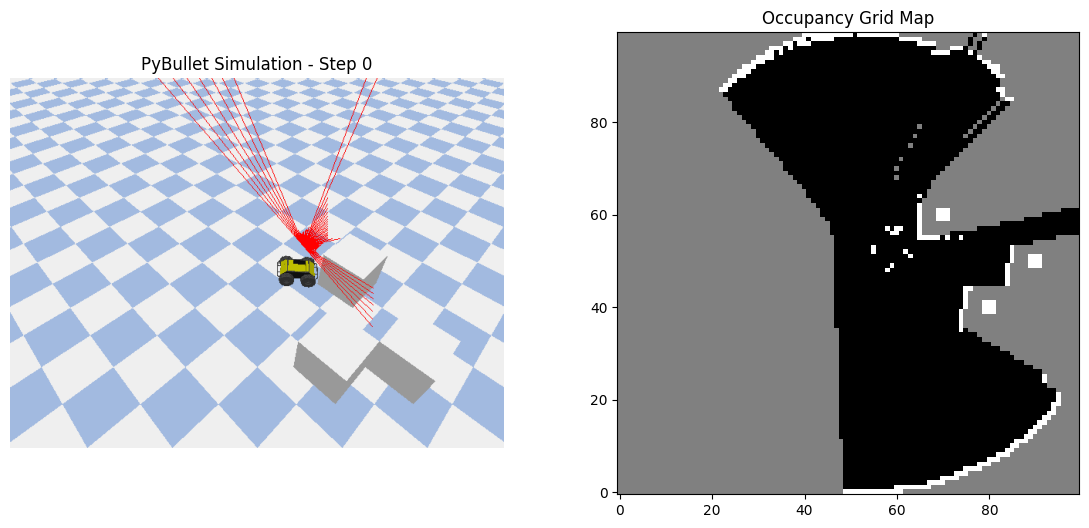

Step: 0
Initial Pose: (1.0046822557832347, 0.36238708468204, 0.7085657697357315)
Refined Pose: (0.8199697914025625, 0.18441029519560923, 0.8098994559298381)


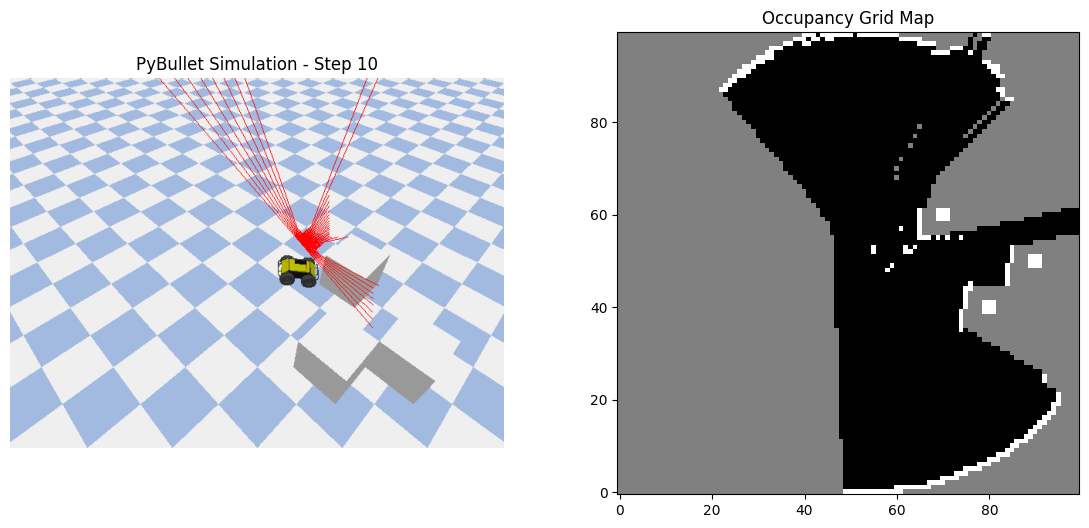

Step: 10
Initial Pose: (1.008851807034902, 0.3622752959455917, 0.7060210870774106)
Refined Pose: (1.1005897788640586, 0.4540497372624282, 0.6323764975317653)


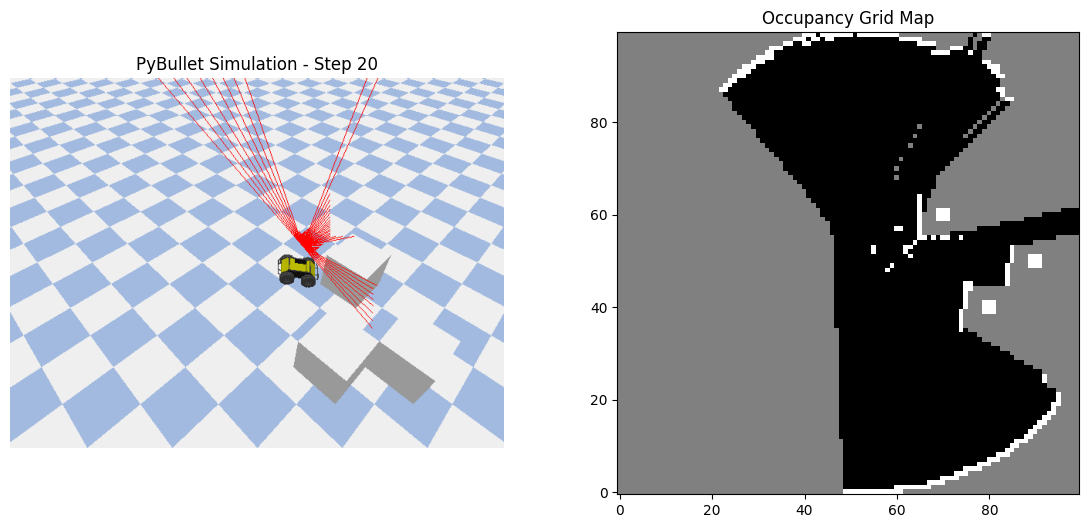

Step: 20
Initial Pose: (0.9986331215399633, 0.3523585999783906, 0.7046834382501797)
Refined Pose: (1.0150846951867503, 0.5127058089017065, 0.6089458609816282)


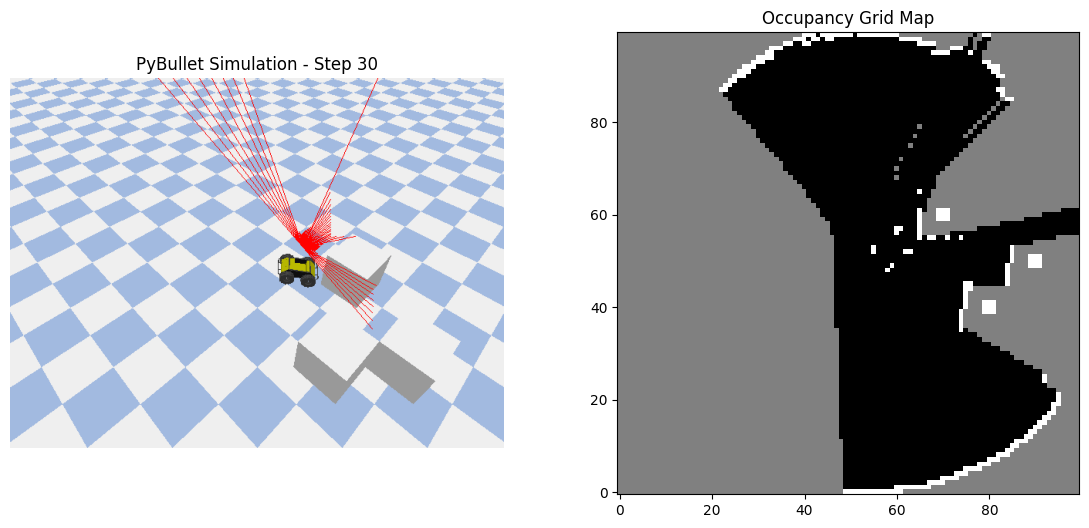

Step: 30
Initial Pose: (0.9938546258651493, 0.34827365516909076, 0.7052633023983356)
Refined Pose: (1.0771563301574103, 0.2700220600874718, 0.7849082573135268)


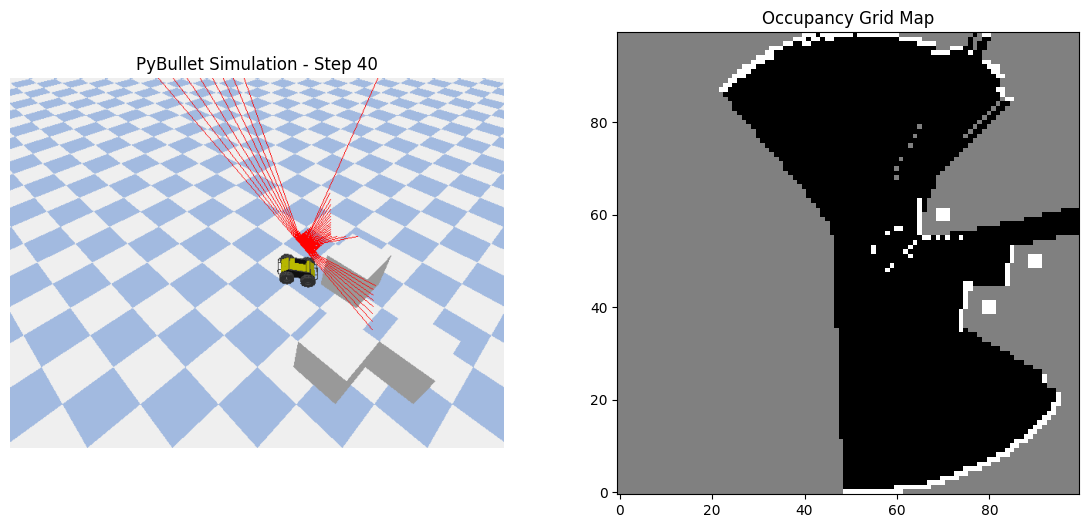

Step: 40
Initial Pose: (0.99044611895056, 0.34244972499487547, 0.7036554370138871)
Refined Pose: (1.0823200693010646, 0.5326919690523886, 0.7393474214321075)


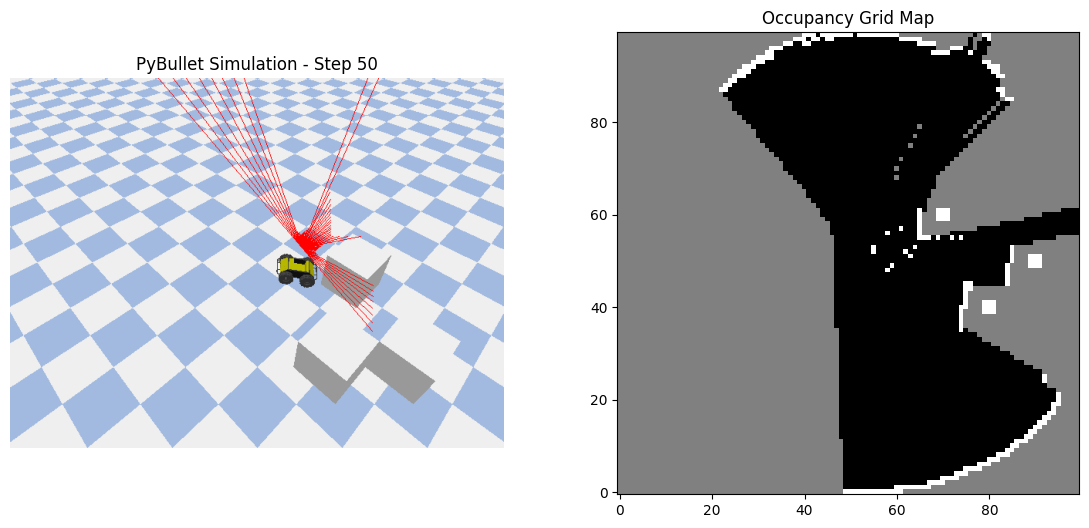

Step: 50
Initial Pose: (0.9779022909802777, 0.32933726293843135, 0.7005807150101125)
Refined Pose: (1.1555754680058503, 0.49353799387320396, 0.5935082224772203)


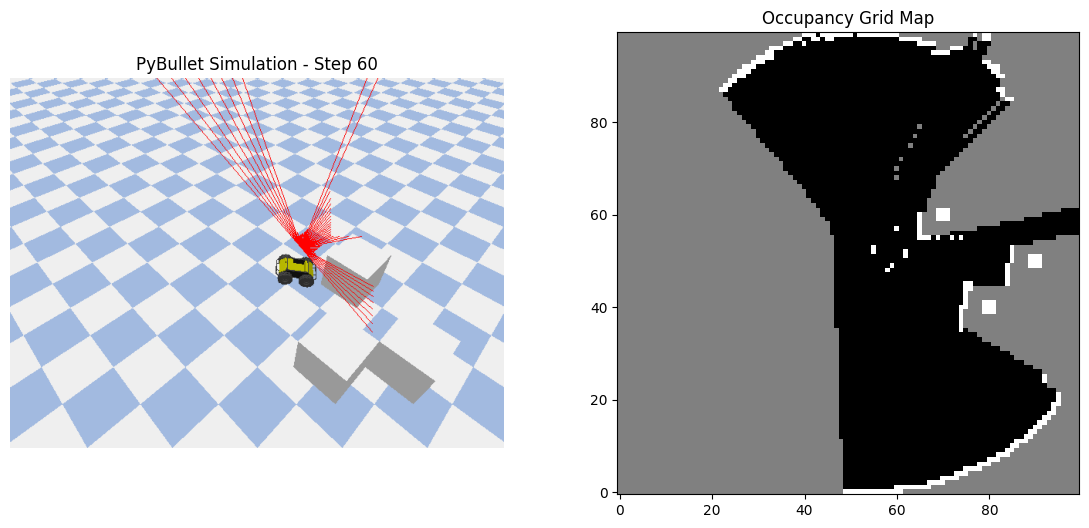

Step: 60
Initial Pose: (0.9666500069325352, 0.3216118606274297, 0.7022118149247055)
Refined Pose: (1.143142670519976, 0.33704323478969334, 0.5577159096303146)


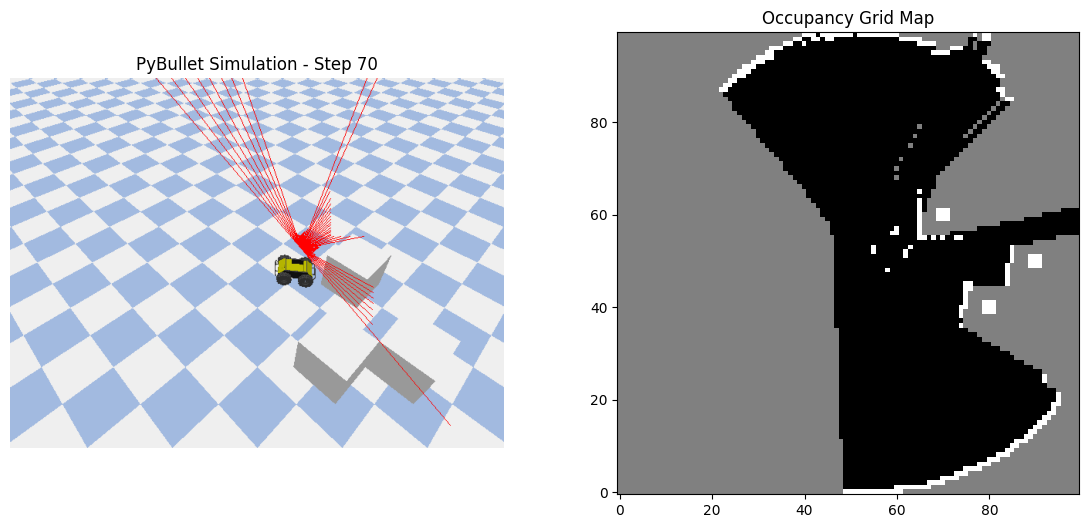

Step: 70
Initial Pose: (0.9560596560836534, 0.31256169127415245, 0.7008123994821118)
Refined Pose: (0.946736010867294, 0.49845423466306926, 0.5401140173062059)


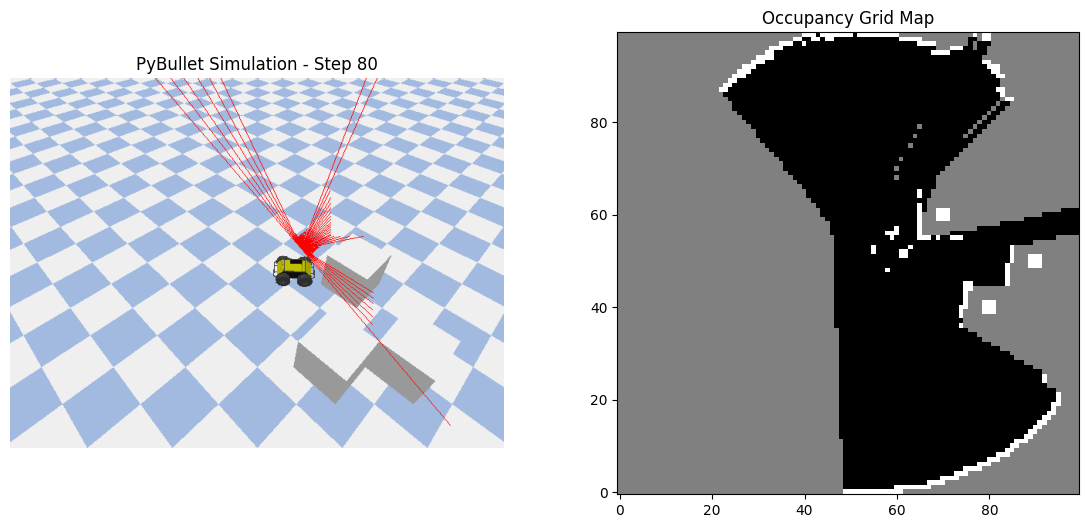

Step: 80
Initial Pose: (0.9512652727086331, 0.31115394416566644, 0.7028722039603844)
Refined Pose: (0.8898197683257426, 0.475888009956609, 0.5783161960788236)


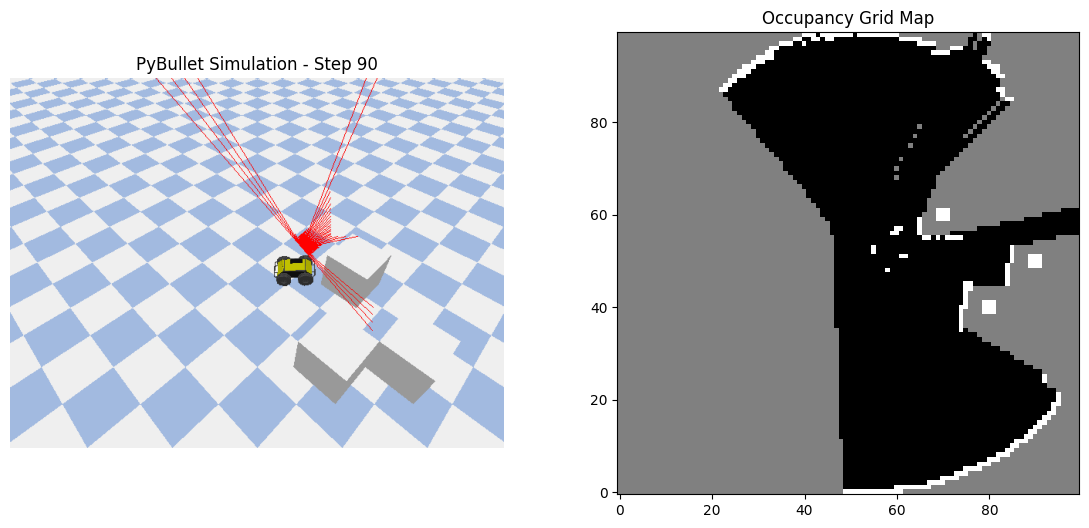

Step: 90
Initial Pose: (0.9754794701133972, 0.3332632362589621, 0.7070526224654091)
Refined Pose: (1.1533882113141682, 0.22586402726375404, 0.5635994150662704)


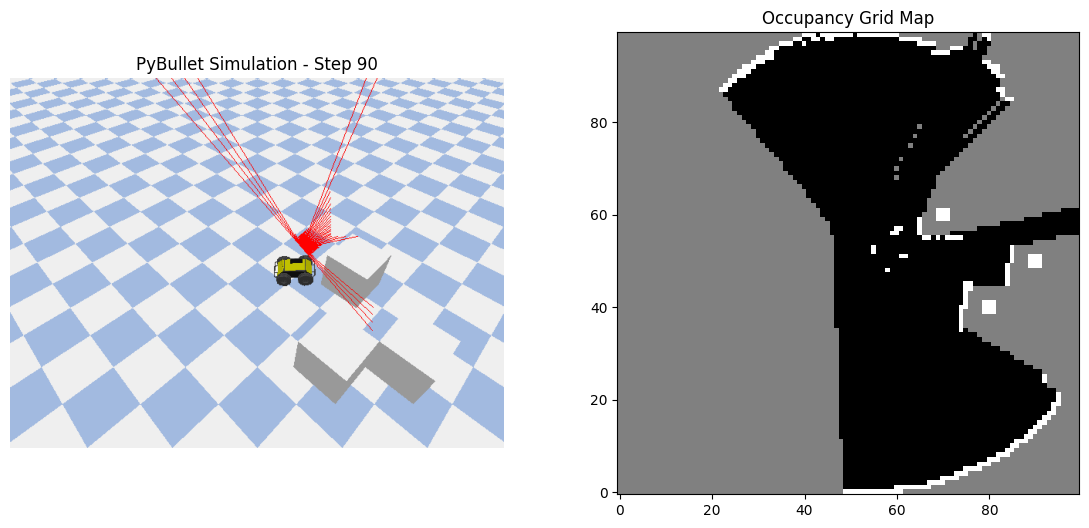

In [ ]:
beam_lines = []
plt.ion()
#plt.figure(figsize=(6, 6))
fig, axs = plt.subplots(1, 2, figsize=(14, 6))
#while True:
for step in range(100):
    p.stepSimulation()

    distances, beam_endpoints, hits, initial_pose = simulate_lidar(robot_id)
    refined_pose = estimate_best_poseN(beam_endpoints, grid_map, initial_pose, distances, dnn_sensor_model)

    # Mark frees and occupied intelligently
    update_map(grid_map, beam_endpoints, refined_pose, hit_max=True)
    pos, _ = p.getBasePositionAndOrientation(robot_id)
    l_speed, r_speed = avoid_obstacles(beam_endpoints, pos)
    drive(robot_id, l_speed, r_speed)

    if step % 10 == 0:
        frame = render_pybullet_with_lidar(robot_id, beam_endpoints)
        axs[0].cla()
        axs[0].imshow(frame)
        axs[0].set_title(f"PyBullet Simulation - Step {step}")
        axs[0].axis("off")
        axs[1].cla()
        axs[1].imshow( grid_map, cmap="gray", origin="lower",vmin=0, vmax=1)
        axs[1].set_title("Occupancy Grid Map")
        display(fig)
        #clear_output(wait=True)
        print("Step:", step)
        print("Initial Pose:", initial_pose)
        print("Refined Pose:", refined_pose)

    time.sleep(1.0 / 240.0)

In [ ]:
p.disconnect()

******************EXERCISE******************
### Perofrm below exercise for practice :
1. Update the function simulate_lidar() to impute a gaussian noise into the sensor reading ie., ray results to simulate the imperfections in the sensor measurements.
2. Instead of generate_candidate_poses() funtion , impute a gaussian noise into the current_pose to simulate the uncertainty of the robot's location. For this case the correlation logic must be changed. Print the amount of confidence in terms of the correlation score.
3. Replace the logic within avoid_obstacles() with MLorDNN(Supervised Learning to perform regression) to predict the turn velocities/heading direction(for both left & right wheel)ie.,Ytarget given all the input arguments ie., Xfeatures. create a synthetic meaningful labelled data for this activity